In [1]:
import pandas as pd
import psycopg2
import os
import pickle
from datetime import datetime, timedelta, date
from pathlib import Path
import numpy as np

In [3]:
from core.database import duck_query
from datetime import datetime, timedelta, date
import pandas as pd


In [4]:
sql = f"""
SELECT * FROM fact_estoque_final    
"""
estoque_total = duck_query(sql)
print(estoque_total.columns)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Index(['id', 'tipomovimentacaoestoqueid', 'embalagemid', 'unidadenegocioid',
       'datahora', 'usuarioid', 'quantidade', 'estoqueanterior', 'estoque',
       'precoreferencial', 'precovenda', 'custo', 'customedio',
       'naoatualizarestoque', 'ultimaalteracaoprecoid', 'conversaoembalagemid',
       'datahorarecalculo', 'customedioanterior', 'estoqueanteriorproduto',
       'custoponderavel', 'origemcustoponderavel', 'embalagem_id',
       'embalagem_produtoid', 'embalagem_codigobarras', 'embalagem_etiqueta',
       'embalagem_descricao', 'embalagem_apresentacao',
       'embalagem_quantidadeporembalagem', 'embalagem_padraofornecedores',
       'embalagem_precoreferencial', 'embalagem_markup',
       'embalagem_precovenda', 'embalagem_precovendavariavel', 'produto_id',
       'produto_status', 'produto_codigo', 'produto_tipopreco',
       'produto_fabricanteid', 'produto_tipoprodutoid',
       'produto_produtoreferenciaid', 'produto_principioativoid',
       'produto_usocontinuo', '

In [5]:
columns = ['descricao_movimentacao', 'embalagemid',
       'datahora', 'quantidade', 'estoqueanterior', 'estoque',
       'precoreferencial', 'precovenda', 'custo', 'customedio',
       'embalagem_precoreferencial', 'embalagem_markup',
       'embalagem_precovenda']

In [6]:
estoque_total[(estoque_total['filial_codigo']=='01') & (estoque_total['embalagem_id']==1055815)&(estoque_total['datahora']>='2025-09-15')][columns]

,descricao_movimentacao,embalagemid,datahora,quantidade,estoqueanterior,estoque,precoreferencial,precovenda,custo,customedio,embalagem_precoreferencial,embalagem_markup,embalagem_precovenda
2091114,Venda,1055815,2025-09-19 18:36:08,-1.0,406.0,405.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
2091511,Venda,1055815,2025-09-19 19:33:38,-1.0,405.0,404.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
2092283,Venda,1055815,2025-09-20 07:20:09,-1.0,404.0,403.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
2092483,Venda,1055815,2025-09-20 07:42:24,-1.0,403.0,402.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
2092484,Venda,1055815,2025-09-20 07:42:24,-1.0,402.0,401.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582570,Venda,1055815,2025-09-19 10:43:28,-1.0,413.0,412.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
3583568,Venda,1055815,2025-09-19 11:19:30,-2.0,412.0,410.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
3584716,Venda,1055815,2025-09-19 12:30:57,-1.0,410.0,409.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38
3584717,Venda,1055815,2025-09-19 12:30:57,-1.0,409.0,408.0,7.51,10.38,1.0332,1.0346,7.51,38.2157,10.38


In [28]:
estoque_total[estoque_total['estoque']>0]['embalagem_id'].nunique()

19385

In [4]:
sql = f"""
SELECT * FROM fact_vendas_final    
"""
vendas = duck_query(sql)
print(vendas.columns)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Index(['venda_id', 'venda_status', 'venda_caixaid', 'venda_unidadenegocioid',
       'venda_usuarioid', 'venda_pessoaid', 'venda_orcamentoid',
       'venda_datahoraabertura', 'venda_datahorafechamento', 'item_sequencia',
       'item_embalagemid', 'item_quantidade', 'item_valorunitario',
       'item_origemdesconto', 'item_tipodesconto', 'item_desconto',
       'item_valortotal', 'item_cadernoofertaid', 'item_valordesconto',
       'item_movimentacaoestoque', 'orcamento_id', 'orcamento_codigo',
       'orcamento_datahora', 'orcamento_usuarioid',
       'orcamento_unidadenegocioid', 'orcamento_formapagamentoid',
       'orcamento_pessoaid', 'orcamento_cpfcnpjconsumidor',
       'embalagem_codigobarras', 'embalagem_etiqueta', 'embalagem_descricao',
       'embalagem_apresentacao', 'embalagem_precoreferencial',
       'embalagem_markup', 'embalagem_precovenda',
       'embalagem_precovendavariavel', 'produto_id', 'produto_status',
       'produto_codigo', 'produto_fabricanteid', 'custome

In [9]:
vendas[(vendas['data_date']=='24/09/2025')&(vendas['embalagem_id']==1055815)][['data_date',
       'item_quantidade','item_valorunitario','item_desconto', 'item_valortotal', 
       'item_valordesconto', 'embalagem_id',
       'embalagem_produtoid', 'embalagem_codigobarras', 'embalagem_etiqueta',
       'embalagem_descricao',  'embalagem_markup',
       'embalagem_precovenda', 'customedio','filial_codigo',
       'customediototal','valordescontototal']]

,data_date,item_quantidade,item_valorunitario,item_desconto,item_valortotal,item_valordesconto,embalagem_id,embalagem_produtoid,embalagem_codigobarras,embalagem_etiqueta,embalagem_descricao,embalagem_markup,embalagem_precovenda,customedio,filial_codigo,customediototal,valordescontototal
2948113,2025-09-24,3.0,10.38,6.59,11.37,6.59,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0346,01,3.1038,19.77
2948139,2025-09-24,1.0,10.38,6.59,3.79,6.59,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0346,01,1.0346,6.59
2948156,2025-09-24,2.0,10.38,4.98,10.80,4.98,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0346,01,2.0692,9.96
2948513,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0346,01,1.0346,6.89
2948872,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0346,01,1.0346,6.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954938,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0437,12,1.0437,6.89
2954967,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0437,12,1.0437,6.89
2955312,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0409,13,1.0409,6.89
2955385,2025-09-24,1.0,10.38,6.89,3.49,6.89,1055815,1055812,7896112114185,044992,LOSARTANA POTASSICA 50 MG C/30 CPR(TEU),38.2157,10.38,1.0409,13,1.0409,6.89


In [53]:
hoje = pd.Timestamp('2025-09-25')
periodo_vendas = 90  # dias
data_limite_ontem = (pd.Timestamp(hoje) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
data_limite_periodo = (pd.Timestamp(data_limite_ontem) - pd.Timedelta(days=periodo_vendas)).strftime('%Y-%m-%d')

sql1 = f"""
-- Curva ABC baseada nos últimos 90 dias de vendas
    SELECT
        e.filial_codigo,
        e.embalagemid,
        e.classificacao_n1,
        COALESCE(pc.curvaABC, 'D') AS curvaABC,
        DATE(e.datahora) AS data_estoque,
        e.estoque,
        e.customedio,
        ROW_NUMBER() OVER (
            PARTITION BY e.filial_codigo, e.embalagemid, DATE(e.datahora)
            ORDER BY e.datahora DESC
        ) AS rn_dia
    FROM fact_estoque_final e
    LEFT JOIN 
    
 (SELECT 
        filial_codigo,
        embalagemid,
        CASE 
            WHEN total_vendas_grupo > 0 AND (quantidade_acum * 100.0 / total_vendas_grupo) <= 50 THEN 'A'
            WHEN total_vendas_grupo > 0 AND (quantidade_acum * 100.0 / total_vendas_grupo) <= 80 THEN 'B'
            WHEN total_vendas_grupo > 0 THEN 'C'
            ELSE 'D'
        END AS curvaABC
    FROM (
    SELECT 
        filial_codigo,
        classificacao_n3,
        embalagemid,
        quantidade_vendida,
        SUM(quantidade_vendida) OVER (
            PARTITION BY filial_codigo, classificacao_n3 
            ORDER BY quantidade_vendida DESC
            ROWS UNBOUNDED PRECEDING
        ) AS quantidade_acum,
        SUM(quantidade_vendida) OVER (PARTITION BY filial_codigo, classificacao_n3) AS total_vendas_grupo
    FROM (
    SELECT 
        filial_codigo,
        classificacao_n3,
        item_embalagemid AS embalagemid,
        SUM(ABS(item_quantidade)) AS quantidade_vendida
    FROM fact_vendas_final
    WHERE data_date >= DATE '{data_limite_periodo}'
    AND data_date <= DATE '{data_limite_ontem}'
    GROUP BY filial_codigo, classificacao_n3, item_embalagemid
) as vendas_por_produto
) as vendas_com_acumulado
) as pc
        ON e.filial_codigo = pc.filial_codigo AND e.embalagemid = pc.embalagemid
    WHERE DATE(e.datahora) >= DATE '{data_limite_periodo}'
    AND DATE(e.datahora) <= DATE '{data_limite_ontem}'
    AND e.estoque >= 0
    AND e.customedio > 0


"""

teste = duck_query(sql1)
teste

,filial_codigo,embalagemid,classificacao_n1,curvaABC,data_estoque,estoque,customedio,rn_dia
0,01,12943629,SBB,C,2025-07-28,0.0,3.3200,1
1,01,13183695,VAREJO,D,2025-08-01,0.0,18.2057,1
2,01,13183695,VAREJO,D,2025-08-01,42.0,18.2057,2
3,01,13183695,VAREJO,D,2025-08-01,21.0,18.2057,3
4,01,13183755,VAREJO,B,2025-08-16,2.0,66.0240,1
...,...,...,...,...,...,...,...,...
859388,04,202010,VAREJO,C,2025-08-27,1.0,7.1400,2
859389,04,202274,VAREJO,C,2025-07-27,5.0,3.5950,1
859390,04,202274,VAREJO,C,2025-09-10,11.0,3.5200,1
859391,04,202400,VAREJO,C,2025-07-21,11.0,3.3500,1


In [57]:
teste[teste['embalagemid']==1055815]

,filial_codigo,embalagemid,classificacao_n1,curvaABC,data_estoque,estoque,customedio,rn_dia
4096,03,1055815,INDICAÇÃO,A,2025-08-06,786.0,0.9362,20
4097,03,1055815,INDICAÇÃO,A,2025-08-06,787.0,0.9362,21
4098,03,1055815,INDICAÇÃO,A,2025-08-06,788.0,0.9362,22
4099,03,1055815,INDICAÇÃO,A,2025-08-06,789.0,0.9362,23
4100,03,1055815,INDICAÇÃO,A,2025-08-06,790.0,0.9362,24
...,...,...,...,...,...,...,...,...
856465,03,1055815,INDICAÇÃO,A,2025-09-02,732.0,0.9988,38
857927,13,1055815,INDICAÇÃO,A,2025-07-29,86.0,0.9267,1
857928,13,1055815,INDICAÇÃO,A,2025-07-29,87.0,0.9267,2
857929,13,1055815,INDICAÇÃO,A,2025-07-29,85.0,0.9267,3


In [56]:
teste.groupby(['filial_codigo','embalagemid']).size().reset_index().sort_values(0, ascending=False)

,filial_codigo,embalagemid,0
24080,04,1055815,5023
17306,03,1055815,3148
49214,09,1055815,2892
43755,08,1055815,2825
19134,04,140360,2790
...,...,...,...
69072,13,14268541,1
69073,13,14291278,1
69074,13,14291283,1
69075,13,14342058,1


In [34]:
hoje = pd.Timestamp('2025-09-25')
periodo_vendas = 90  # dias
data_limite_ontem = (pd.Timestamp(hoje) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
data_limite_periodo = (pd.Timestamp(data_limite_ontem) - pd.Timedelta(days=periodo_vendas)).strftime('%Y-%m-%d')

sql = f"""
-- Curva ABC baseada nos últimos 90 dias de vendas
WITH vendas_90d_abc AS (
    SELECT 
        filial_codigo,
        classificacao_n3,
        item_embalagemid AS embalagemid,
        SUM(ABS(item_quantidade)) AS quantidade_vendida
    FROM fact_vendas_final
    WHERE data_date >= DATE '{data_limite_periodo}'
    AND data_date <= DATE '{data_limite_ontem}'
    GROUP BY filial_codigo, classificacao_n3, item_embalagemid
),
vendas_com_acumulado AS (
    SELECT 
        filial_codigo,
        classificacao_n3,
        embalagemid,
        quantidade_vendida,
        SUM(quantidade_vendida) OVER (
            PARTITION BY filial_codigo, classificacao_n3 
            ORDER BY quantidade_vendida DESC
            ROWS UNBOUNDED PRECEDING
        ) AS quantidade_acum,
        SUM(quantidade_vendida) OVER (PARTITION BY filial_codigo, classificacao_n3) AS total_vendas_grupo
    FROM vendas_90d_abc
),
produtos_com_curva AS (
    SELECT 
        filial_codigo,
        embalagemid,
        CASE 
            WHEN total_vendas_grupo > 0 AND (quantidade_acum * 100.0 / total_vendas_grupo) <= 50 THEN 'A'
            WHEN total_vendas_grupo > 0 AND (quantidade_acum * 100.0 / total_vendas_grupo) <= 80 THEN 'B'
            WHEN total_vendas_grupo > 0 THEN 'C'
            ELSE 'D'
        END AS curvaABC
    FROM vendas_com_acumulado
),
vendas_periodo AS (
    SELECT
        v.filial_codigo,
        v.item_embalagemid AS embalagemid,
        v.data_date,
        v.classificacao_n1,
        COALESCE(pc.curvaABC, 'D') AS curvaABC,
        ABS(v.item_quantidade) AS quantidade_vendida,
        v.item_valorunitario,
        COALESCE(v.item_desconto, 0) AS item_desconto,
        (v.item_valorunitario - COALESCE(v.item_desconto, 0)) AS item_precoaposdesconto,
        v.customedio,
        -- Receita real (preço após desconto)
        (v.item_valorunitario - COALESCE(v.item_desconto, 0)) * ABS(v.item_quantidade) AS receita_real,
        -- Custo das mercadorias vendidas
        v.customedio * ABS(v.item_quantidade) AS cmv_real,
        -- Margem bruta real
        ((v.item_valorunitario - COALESCE(v.item_desconto, 0)) * ABS(v.item_quantidade)) - (v.customedio * ABS(v.item_quantidade)) AS margem_bruta_real
    FROM fact_vendas_final v
    LEFT JOIN produtos_com_curva pc
        ON v.filial_codigo = pc.filial_codigo AND v.item_embalagemid = pc.embalagemid
    WHERE v.data_date >= DATE '{data_limite_periodo}'
    AND v.data_date <= DATE '{data_limite_ontem}'
    AND v.customedio > 0
    AND v.item_valorunitario > 0
),
-- CORREÇÃO: Estoque final de cada dia (última movimentação do dia)
estoque_diario AS (
    SELECT
        e.filial_codigo,
        e.embalagemid,
        e.classificacao_n1,
        COALESCE(pc.curvaABC, 'D') AS curvaABC,
        DATE(e.datahora) AS data_estoque,
        e.estoque,
        e.customedio,
        ROW_NUMBER() OVER (
            PARTITION BY e.filial_codigo, e.embalagemid, DATE(e.datahora)
            ORDER BY e.datahora DESC
        ) AS rn_dia
    FROM fact_estoque_final e
    LEFT JOIN produtos_com_curva pc
        ON e.filial_codigo = pc.filial_codigo AND e.embalagemid = pc.embalagemid
    WHERE DATE(e.datahora) >= DATE '{data_limite_periodo}'
    AND DATE(e.datahora) <= DATE '{data_limite_ontem}'
    AND e.estoque >= 0
    AND e.customedio > 0
),
-- Estoque médio baseado apenas no estoque final de cada dia
estoque_medio AS (
    SELECT
        filial_codigo,
        embalagemid,
        classificacao_n1,
        curvaABC,
        AVG(customedio * estoque) AS valor_estoque_medio
    FROM estoque_diario
    WHERE rn_dia = 1  -- Apenas a última movimentação de cada dia
    GROUP BY filial_codigo, embalagemid, classificacao_n1, curvaABC
)
-- 1) Por curva ABC (geral da rede)
SELECT
    'Geral' AS filial_codigo,
    vp.curvaABC,
    'Geral' AS classificacao_n1,
    {periodo_vendas} AS periodo_dias,
    SUM(vp.receita_real) AS receita_real_vendas,
    SUM(vp.cmv_real) AS cmv_vendas,
    SUM(vp.margem_bruta_real) AS margem_bruta_vendas,
    COALESCE(SUM(em.valor_estoque_medio), 0) AS valor_medio_estoque,
    COUNT(*) AS total_transacoes,
    SUM(vp.quantidade_vendida) AS total_quantidade_vendida,
    COUNT(DISTINCT em.embalagemid) AS total_produtos_estoque,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN (SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)) * 100
        ELSE 0 
    END AS gmroi_percentual,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)
        ELSE 0 
    END AS gmroi_ratio
FROM vendas_periodo vp
LEFT JOIN estoque_medio em
    ON vp.filial_codigo = em.filial_codigo 
    AND vp.embalagemid = em.embalagemid
    AND vp.curvaABC = em.curvaABC
WHERE vp.curvaABC IS NOT NULL
GROUP BY vp.curvaABC

UNION ALL

-- 2) Por curva ABC + filial
SELECT
    vp.filial_codigo,
    vp.curvaABC,
    'Geral' AS classificacao_n1,
    {periodo_vendas} AS periodo_dias,
    SUM(vp.receita_real) AS receita_real_vendas,
    SUM(vp.cmv_real) AS cmv_vendas,
    SUM(vp.margem_bruta_real) AS margem_bruta_vendas,
    COALESCE(SUM(em.valor_estoque_medio), 0) AS valor_medio_estoque,
    COUNT(*) AS total_transacoes,
    SUM(vp.quantidade_vendida) AS total_quantidade_vendida,
    COUNT(DISTINCT em.embalagemid) AS total_produtos_estoque,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN (SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)) * 100
        ELSE 0 
    END AS gmroi_percentual,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)
        ELSE 0 
    END AS gmroi_ratio
FROM vendas_periodo vp
LEFT JOIN estoque_medio em
    ON vp.filial_codigo = em.filial_codigo 
    AND vp.embalagemid = em.embalagemid
    AND vp.curvaABC = em.curvaABC
WHERE vp.curvaABC IS NOT NULL
GROUP BY vp.filial_codigo, vp.curvaABC

UNION ALL

-- 3) Por classificacao_n1 (geral da rede)
SELECT
    'Geral' AS filial_codigo,
    'Geral' AS curvaABC,
    vp.classificacao_n1,
    {periodo_vendas} AS periodo_dias,
    SUM(vp.receita_real) AS receita_real_vendas,
    SUM(vp.cmv_real) AS cmv_vendas,
    SUM(vp.margem_bruta_real) AS margem_bruta_vendas,
    COALESCE(SUM(em.valor_estoque_medio), 0) AS valor_medio_estoque,
    COUNT(*) AS total_transacoes,
    SUM(vp.quantidade_vendida) AS total_quantidade_vendida,
    COUNT(DISTINCT em.embalagemid) AS total_produtos_estoque,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN (SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)) * 100
        ELSE 0 
    END AS gmroi_percentual,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)
        ELSE 0 
    END AS gmroi_ratio
FROM vendas_periodo vp
LEFT JOIN estoque_medio em
    ON vp.filial_codigo = em.filial_codigo 
    AND vp.embalagemid = em.embalagemid
    AND vp.classificacao_n1 = em.classificacao_n1
WHERE vp.classificacao_n1 IS NOT NULL
GROUP BY vp.classificacao_n1

UNION ALL

-- 4) Por curva ABC + classificacao_n1 (geral da rede)
SELECT
    'Geral' AS filial_codigo,
    vp.curvaABC,
    vp.classificacao_n1,
    {periodo_vendas} AS periodo_dias,
    SUM(vp.receita_real) AS receita_real_vendas,
    SUM(vp.cmv_real) AS cmv_vendas,
    SUM(vp.margem_bruta_real) AS margem_bruta_vendas,
    COALESCE(SUM(em.valor_estoque_medio), 0) AS valor_medio_estoque,
    COUNT(*) AS total_transacoes,
    SUM(vp.quantidade_vendida) AS total_quantidade_vendida,
    COUNT(DISTINCT em.embalagemid) AS total_produtos_estoque,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN (SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)) * 100
        ELSE 0 
    END AS gmroi_percentual,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)
        ELSE 0 
    END AS gmroi_ratio
FROM vendas_periodo vp
LEFT JOIN estoque_medio em
    ON vp.filial_codigo = em.filial_codigo 
    AND vp.embalagemid = em.embalagemid
    AND vp.curvaABC = em.curvaABC
    AND vp.classificacao_n1 = em.classificacao_n1
WHERE vp.curvaABC IS NOT NULL AND vp.classificacao_n1 IS NOT NULL
GROUP BY vp.curvaABC, vp.classificacao_n1

UNION ALL

-- 5) Por curva ABC + filial + classificacao_n1
SELECT
    vp.filial_codigo,
    vp.curvaABC,
    vp.classificacao_n1,
    {periodo_vendas} AS periodo_dias,
    SUM(vp.receita_real) AS receita_real_vendas,
    SUM(vp.cmv_real) AS cmv_vendas,
    SUM(vp.margem_bruta_real) AS margem_bruta_vendas,
    COALESCE(SUM(em.valor_estoque_medio), 0) AS valor_medio_estoque,
    COUNT(*) AS total_transacoes,
    SUM(vp.quantidade_vendida) AS total_quantidade_vendida,
    COUNT(DISTINCT em.embalagemid) AS total_produtos_estoque,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN (SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)) * 100
        ELSE 0 
    END AS gmroi_percentual,
    CASE 
        WHEN COALESCE(SUM(em.valor_estoque_medio), 0) > 0 
        THEN SUM(vp.margem_bruta_real) / SUM(em.valor_estoque_medio)
        ELSE 0 
    END AS gmroi_ratio
FROM vendas_periodo vp
LEFT JOIN estoque_medio em
    ON vp.filial_codigo = em.filial_codigo 
    AND vp.embalagemid = em.embalagemid
    AND vp.curvaABC = em.curvaABC
    AND vp.classificacao_n1 = em.classificacao_n1
WHERE vp.curvaABC IS NOT NULL AND vp.classificacao_n1 IS NOT NULL
GROUP BY vp.filial_codigo, vp.curvaABC, vp.classificacao_n1

ORDER BY filial_codigo, curvaABC, classificacao_n1
"""

df = duck_query(sql)

# Formatar resultado
df['periodo_dias'] = df['periodo_dias'].astype(int)
df['receita_real_vendas'] = df['receita_real_vendas'].round(2)
df['cmv_vendas'] = df['cmv_vendas'].round(2)
df['margem_bruta_vendas'] = df['margem_bruta_vendas'].round(2)
df['valor_medio_estoque'] = df['valor_medio_estoque'].round(2)
df['total_transacoes'] = df['total_transacoes'].astype(int)
df['total_quantidade_vendida'] = df['total_quantidade_vendida'].round(2)
df['total_produtos_estoque'] = df['total_produtos_estoque'].astype(int)
df['gmroi_percentual'] = df['gmroi_percentual'].round(4)
df['gmroi_ratio'] = df['gmroi_ratio'].round(4)

In [38]:
df[(df['filial_codigo']=='Geral')&(df['curvaABC']=='Geral')]['valor_medio_estoque'].sum()

np.float64(447925596.89)

In [15]:
data_limite = '2025-09-19 23:59:59'  # data do último dia completo disponível no sistema

In [28]:
# Valor total do estoque (pelo custo médio)
sql_valor_total = f"""
WITH estoque_atual AS (
    SELECT
        filial_codigo,
        embalagemid,
        estoque,
        customedio,
        (customedio * estoque) AS valor_estoque,
        ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
    FROM fact_estoque_final
    WHERE datahora <= DATE '{data_limite}'
)
SELECT
    SUM(valor_estoque) AS valor_total_estoque
FROM estoque_atual
WHERE rn = 1
"""

df_valor = duck_query(sql_valor_total)
valor_total = df_valor['valor_total_estoque'].iloc[0] if df_valor is not None else 0

# Quantidade de linhas
sql_linhas = f"""
SELECT COUNT(*) AS total_linhas
FROM fact_estoque_final
WHERE datahora <= DATE '{data_limite}'
"""

df_linhas = duck_query(sql_linhas)
total_linhas = df_linhas['total_linhas'].iloc[0] if df_linhas is not None else 0

# Produtos únicos por filial
sql_produtos_filial = f"""
WITH estoque_atual AS (
    SELECT
        filial_codigo,
        embalagemid,
        ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
    FROM fact_estoque_final
    WHERE datahora <= DATE '{data_limite}'
)
SELECT
    filial_codigo,
    COUNT(DISTINCT embalagemid) AS produtos_unicos
FROM estoque_atual
WHERE rn = 1
GROUP BY filial_codigo
ORDER BY filial_codigo
"""

df_produtos_filial = duck_query(sql_produtos_filial)

In [29]:
df_produtos_filial

,filial_codigo,produtos_unicos
0,01,12791
1,02,8200
2,03,9901
3,04,11106
4,05,9022
5,06,6664
6,07,8436
7,08,8571
8,09,9255
9,10,6890


In [27]:
print(f"Valor total do estoque (pelo custo médio): R$ {valor_total:,.2f}")
print(f"Total de linhas na tabela de estoque até {data_limite}: {total_linhas:,}")
print("Produtos únicos por filial (até a data limite): {df_produtos_filial}")

print(f"Valor total do estoque (custo médio, até {cutoff}): R$ {valor_total:,.2f}")
print(f"Total de linhas até {cutoff}: {total_linhas:,}")

Valor total do estoque (pelo custo médio): R$ 7,794,642.98
Total de linhas na tabela de estoque até 2025-09-19 23:59:59: 3,793,702
Produtos únicos por filial (até a data limite): {df_produtos_filial}
Valor total do estoque (custo médio, até 2025-09-19 23:59:59): R$ 7,794,642.98
Total de linhas até 2025-09-19 23:59:59: 3,793,702


In [24]:
estoque['datahora'] = pd.to_datetime(estoque['datahora'], errors='coerce')
cutoff = pd.to_datetime('2025-09-19 23:59:59')

# filtrar até a data limite
estoque_upto = estoque[estoque['datahora'] <= cutoff].copy()

# total de linhas até cutoff
total_linhas = len(estoque_upto)

# garantir numéricos
estoque_upto['estoque'] = pd.to_numeric(estoque_upto.get('estoque', 0), errors='coerce').fillna(0)
estoque_upto['customedio'] = pd.to_numeric(estoque_upto.get('customedio', 0), errors='coerce').fillna(0)

# pegar a última movimentação por filial+embalagem (equivalente a rn = 1)
latest = (estoque_upto.sort_values('datahora')
          .drop_duplicates(subset=['filial_codigo', 'embalagemid'], keep='last')
         )

# calcular valor_estoque e somar
latest['valor_estoque'] = latest['estoque'] * latest['customedio']
valor_total = latest['valor_estoque'].sum()

# produtos únicos por filial (a partir dos registros mais recentes)
produtos_por_filial = latest.groupby('filial_codigo')['embalagemid'].nunique().reset_index(name='produtos_unicos')

# exibir
print(f"Valor total do estoque (custo médio, até {cutoff}): R$ {valor_total:,.2f}")
print(f"Total de linhas até {cutoff}: {total_linhas:,}")
display(produtos_por_filial)

Valor total do estoque (custo médio, até 2025-09-19 23:59:59): R$ 7,794,642.98
Total de linhas até 2025-09-19 23:59:59: 3,793,702


,filial_codigo,produtos_unicos
0,01,12801
1,02,8205
2,03,9906
3,04,11113
4,05,9034
5,06,6671
6,07,8443
7,08,8580
8,09,9270
9,10,6899


In [4]:
with open(r'data_cache\daily_pkl\final_vendas_completas.pkl', 'rb') as f:
    vendas = pickle.load(f)
with open(r'data_cache\daily_pkl\final_estoque_completo.pkl', 'rb') as f:
    estoque = pickle.load(f)

In [13]:
data_limite_ontem = (date.today() - timedelta(days=1)).strftime('%Y-%m-%d')

In [14]:
sql_totais_duck = f"""
    WITH estoque_atual AS (
        SELECT
            filial_codigo,
            embalagemid,
            estoque,
            customedio,
            (customedio * estoque) AS valor_estoque,
            ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
        FROM fact_estoque_final
        WHERE datahora <= DATE '{data_limite_ontem}'
    )
    SELECT
        COUNT(*) AS total_linhas,
        SUM(estoque) AS total_unidades,
        SUM(valor_estoque) AS total_valor_estoque,
        COUNT(DISTINCT filial_codigo) AS filiais_distintas,
        COUNT(DISTINCT embalagemid) AS produtos_distintos
    FROM estoque_atual
    WHERE rn = 1
    """
df_totais_duck = duck_query(sql_totais_duck)
df_totais_duck

,total_linhas,total_unidades,total_valor_estoque,filiais_distintas,produtos_distintos
0,116355,491704.0,7.731077e+06,13,19441


In [11]:
print(estoque[estoque['datahora']<='2025-09-19 23:59:59'].shape)
print(estoque[estoque['datahora']<='2025-09-19 23:59:59']['estoque'].sum())

(3793702, 61)
399537276.0


In [12]:
sql = """SELECT 
            COUNT(*) as total_linhas,
            COUNT(DISTINCT filial_codigo) as filiais_distintas,
            COUNT(DISTINCT embalagemid) as produtos_distintos,
            MIN(datahora) as data_mais_antiga,
            MAX(datahora) as data_mais_recente,
            SUM(estoque) as soma_estoque
        FROM fact_estoque_final
        where datahora <= '2025-09-19 23:59:59'
        """
df_vendas = duck_query(sql)
df_vendas

,total_linhas,filiais_distintas,produtos_distintos,data_mais_antiga,data_mais_recente,soma_estoque
0,3793702,13,19457,2024-07-09,2025-09-19 21:59:38,399537276.0


In [25]:
data_atual = date.today().strftime('%Y-%m-%d')
data_limite_90 = (pd.Timestamp(data_atual) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
data_limite_30 = (pd.Timestamp(data_atual) - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
data_limite_ontem = (pd.Timestamp(data_atual) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')

In [27]:
sql = f"""WITH vendas_30d AS (
        SELECT 
            SUM(ABS(item_quantidade) * COALESCE(customedio,0)) AS cmv_vendido_30d
        FROM fact_vendas_final
        WHERE data_date >= DATE '{data_limite_30}' AND data_date <= DATE '{data_limite_ontem}'
    ),
    estoque_ultimo AS (
        SELECT
            SUM(COALESCE(customedio,0) * estoque) AS stock_cmv
        FROM (
            SELECT
                filial_codigo,
                embalagemid,
                estoque,
                customedio,
                ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
            FROM fact_estoque_final
            WHERE datahora <= DATE '{data_limite_ontem}'
        ) t
        WHERE t.rn = 1
    )
    SELECT
        e.stock_cmv,
        v.cmv_vendido_30d,
        CASE WHEN v.cmv_vendido_30d > 0 THEN e.stock_cmv / v.cmv_vendido_30d ELSE NULL END AS cobertura_ratio
    FROM estoque_ultimo e CROSS JOIN vendas_30d v
    
    """
df = duck_query(sql)
df.head()

,stock_cmv,cmv_vendido_30d,cobertura_ratio
0,7.730428e+06,3.581811e+06,2.158245


In [ ]:
sql = "SELECT * FROM fact_vendas_final LIMIT 0"
df_columns = duck_query(sql)
df_columns.columns.tolist()

In [15]:
sql = f"""SELECT
        filial_codigo,
        classificacao_n1,
        classificacao_n2,
        classificacao_n3,
        item_embalagemid AS embalagemid,
        SUM(ABS(item_quantidade) * customedio) AS cmv_vendido
    FROM fact_vendas_final
    WHERE data_date >= DATE '{data_limite_90}' and data_date <= DATE '{data_limite_ontem}'
    GROUP BY filial_codigo, classificacao_n1, classificacao_n2, classificacao_n3, item_embalagemid"""
vendas_90d_cmv = duck_query(sql)
vendas_90d_cmv.head()

,filial_codigo,classificacao_n1,classificacao_n2,classificacao_n3,embalagemid,cmv_vendido
0,01,VAREJO,TINTURAS,,327195,148.4100
1,01,SBB,LINHA CAPILAR,,10013649,94.8300
2,01,SBB,HOSPITALAR,,407458,566.7120
3,01,INDICAÇÃO,SIMILARES,SIMILAR FARMACIA POPULAR,143999,6826.8012
4,01,PRESCRIÇÃO,PRODUTOS OL,REFERENCIA OL,326503,245.8494


In [ ]:
sql = f"""SELECT
        filial_codigo,
        embalagemid,
        estoque,
        customedio AS custo_medio,
        customedio * estoque AS valor_estoque,
        classificacao_n1,
        classificacao_n2,
        classificacao_n3
    FROM (
        SELECT
            filial_codigo,
            embalagemid,
            estoque,
            customedio,
            classificacao_n1,
            classificacao_n2,
            classificacao_n3,
            ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
        FROM fact_estoque_final
        WHERE datahora >= DATE '{data_limite_90}' and datahora <= DATE '{data_limite_ontem}'
    ) sub
    WHERE rn = 1"""
estoque_ultimo = duck_query(sql)
estoque_ultimo.head()

,filial_codigo,embalagemid,estoque,custo_medio,valor_estoque,classificacao_n1,classificacao_n2,classificacao_n3
0,01,392966,6.0,11.9900,71.9400,SBB,CUIDADOS COM A PELE,
1,01,406990,2.0,69.7793,139.5586,VAREJO,LEITE,
2,01,407100,33.0,5.2477,173.1741,PRESCRIÇÃO,PRODUTOS OL,REFERENCIA OL - FRACIONADO
3,01,407528,6.0,53.6858,322.1148,VAREJO,LEITE,
4,01,409518,0.0,50.0500,0.0000,PRESCRIÇÃO,MEDICAMENTO REFERENCIA,REFERENCIA


In [20]:
sql = f"""
    SELECT estoque_ultimo.*
    FROM (SELECT
        filial_codigo,
        embalagemid,
        estoque,
        customedio AS custo_medio,
        customedio * estoque AS valor_estoque,
        classificacao_n1,
        classificacao_n2,
        classificacao_n3
    FROM (
        SELECT
            filial_codigo,
            embalagemid,
            estoque,
            customedio,
            classificacao_n1,
            classificacao_n2,
            classificacao_n3,
            ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
        FROM fact_estoque_final
        WHERE datahora >= DATE '{data_limite_90}' and datahora <= DATE '{data_limite_ontem}'
    ) sub
    WHERE rn = 1) as estoque_ultimo
    INNER JOIN (
        SELECT DISTINCT filial_codigo, embalagemid
        FROM fact_estoque_final
        WHERE datahora >= DATE '{data_limite_90}' AND datahora <= DATE '{data_limite_ontem}' AND descricao_movimentacao = 'Recebimento Físico'
    ) compras90 ON estoque_ultimo.filial_codigo = compras90.filial_codigo AND estoque_ultimo.embalagemid = compras90.embalagemid"""
estoque_filtrado = duck_query(sql)
estoque_filtrado.head()

,filial_codigo,embalagemid,estoque,custo_medio,valor_estoque,classificacao_n1,classificacao_n2,classificacao_n3
0,01,551274,1.0,44.5267,44.5267,PRESCRIÇÃO,PRODUTOS OL,PRODUTOS LIBERADOS OL
1,01,551750,3.0,318.8050,956.4150,PRESCRIÇÃO,MEDICAMENTO REFERENCIA,REFERENCIA
2,01,556174,3.0,18.2850,54.8550,INDICAÇÃO,SIMILARES,SIMILAR CRITICO
3,01,557770,17.0,3.8348,65.1916,SBB,LINHA INTIMA,
4,01,566574,1.0,25.0300,25.0300,SBB,LINHA CAPILAR,


In [22]:
sql = f"""
    WITH vendas_30d_produtos AS (
        -- produtos com venda nos últimos 30 dias (para 'teve_giro')
        SELECT DISTINCT filial_codigo, item_embalagemid AS embalagemid
        FROM fact_vendas_final
        WHERE data_date >= DATE '{data_limite_30}' and data_date <= DATE '{data_limite_ontem}'
    ),
    vendas_90d_cmv AS (
        -- cmv vendido nos últimos 90 dias por produto (fallback para item_customedio)
        SELECT
            filial_codigo,
            classificacao_n1,
            classificacao_n2,
            classificacao_n3,
            item_embalagemid AS embalagemid,
            SUM(ABS(item_quantidade) * customedio) AS cmv_vendido
        FROM fact_vendas_final
        WHERE data_date >= DATE '{data_limite_90}' and data_date <= DATE '{data_limite_ontem}'
        GROUP BY filial_codigo, classificacao_n1, classificacao_n2, classificacao_n3, item_embalagemid
    ),
    estoque_ultimo AS (
        -- estoque atual: último registro por filial+embalagem (usa cmv ou customedio como custo médio)
        SELECT
            filial_codigo,
            embalagemid,
            estoque,
            customedio AS custo_medio,
            customedio * estoque AS valor_estoque,
            classificacao_n1,
            classificacao_n2,
            classificacao_n3
        FROM (
            SELECT
                filial_codigo,
                embalagemid,
                estoque,
                customedio,
                classificacao_n1,
                classificacao_n2,
                classificacao_n3,
                ROW_NUMBER() OVER (PARTITION BY filial_codigo, embalagemid ORDER BY datahora DESC) AS rn
            FROM fact_estoque_final
            WHERE datahora >= DATE '{data_limite_90}' and datahora <= DATE '{data_limite_ontem}'
        ) sub
        WHERE rn = 1
    ),
    estoque_filtrado AS (
        -- manter apenas produtos que tiveram RECEBIMENTO nos 90d e vendas nos 30d (mesma lógica de denominação)
        SELECT e.*
        FROM estoque_ultimo e
        INNER JOIN (
            SELECT DISTINCT filial_codigo, embalagemid
            FROM fact_estoque_final
            WHERE datahora >= DATE '{data_limite_90}' and datahora <= DATE '{data_limite_ontem}' AND descricao_movimentacao = 'Recebimento Físico'
        ) compras90 ON e.filial_codigo = compras90.filial_codigo AND e.embalagemid = compras90.embalagemid
    ),
    dados_combinados AS (
        -- marca teve_giro e calcula cmv_com_giro
        SELECT
            ef.filial_codigo,
            ef.embalagemid,
            ef.estoque,
            ef.custo_medio,
            ef.valor_estoque,
            ef.classificacao_n1,
            ef.classificacao_n2,
            ef.classificacao_n3,
            CASE WHEN v30.embalagemid IS NOT NULL THEN 1 ELSE 0 END AS teve_giro,
            CASE WHEN v30.embalagemid IS NOT NULL THEN ef.valor_estoque ELSE 0 END AS cmv_com_giro
        FROM estoque_filtrado ef
        LEFT JOIN vendas_30d_produtos v30
            ON ef.filial_codigo = v30.filial_codigo AND ef.embalagemid = v30.embalagemid
    )
    -- Agregações: Geral, por filial, por curva/classificacao etc.
    SELECT
        'Geral' AS filial_codigo,
        'Geral' AS classificacao_n1,
        'Geral' AS classificacao_n2,
        'Geral' AS classificacao_n3,
        COUNT(*) AS total_produtos,
        SUM(valor_estoque) AS total_valor_estoque,
        SUM(cmv_com_giro) AS valor_estoque_com_giro,
        SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
        CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
    FROM dados_combinados

    UNION ALL

    SELECT
        filial_codigo,
        'Geral' AS classificacao_n1,
        'Geral' AS classificacao_n2,
        'Geral' AS classificacao_n3,
        COUNT(*) AS total_produtos,
        SUM(valor_estoque) AS total_valor_estoque,
        SUM(cmv_com_giro) AS valor_estoque_com_giro,
        SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
        CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
    FROM dados_combinados
    GROUP BY filial_codigo

    UNION ALL

    SELECT
        'Geral' AS filial_codigo,
        classificacao_n1,
        'Geral' AS classificacao_n2,
        'Geral' AS classificacao_n3,
        COUNT(*) AS total_produtos,
        SUM(valor_estoque) AS total_valor_estoque,
        SUM(cmv_com_giro) AS valor_estoque_com_giro,
        SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
        CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
    FROM dados_combinados
    WHERE classificacao_n1 IS NOT NULL
    GROUP BY classificacao_n1
    """
df = duck_query(sql)
df.shape

(18, 9)

In [ ]:
dados_combinados AS (
    -- marca teve_giro e calcula cmv_com_giro
    SELECT
        ef.filial_codigo,
        ef.embalagemid,
        ef.estoque,
        ef.custo_medio,
        ef.valor_estoque,
        ef.classificacao_n1,
        ef.classificacao_n2,
        ef.classificacao_n3,
        CASE WHEN v30.embalagemid IS NOT NULL THEN 1 ELSE 0 END AS teve_giro,
        CASE WHEN v30.embalagemid IS NOT NULL THEN ef.valor_estoque ELSE 0 END AS cmv_com_giro
    FROM estoque_filtrado ef
    LEFT JOIN vendas_30d_produtos v30
        ON ef.filial_codigo = v30.filial_codigo AND ef.embalagemid = v30.embalagemid
)
-- Agregações: Geral, por filial, por curva/classificacao etc.
SELECT
    'Geral' AS filial_codigo,
    'Geral' AS classificacao_n1,
    'Geral' AS classificacao_n2,
    'Geral' AS classificacao_n3,
    COUNT(*) AS total_produtos,
    SUM(valor_estoque) AS total_valor_estoque,
    SUM(cmv_com_giro) AS valor_estoque_com_giro,
    SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
    CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
FROM dados_combinados

UNION ALL

SELECT
    filial_codigo,
    'Geral' AS classificacao_n1,
    'Geral' AS classificacao_n2,
    'Geral' AS classificacao_n3,
    COUNT(*) AS total_produtos,
    SUM(valor_estoque) AS total_valor_estoque,
    SUM(cmv_com_giro) AS valor_estoque_com_giro,
    SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
    CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
FROM dados_combinados
GROUP BY filial_codigo

UNION ALL

SELECT
    'Geral' AS filial_codigo,
    classificacao_n1,
    'Geral' AS classificacao_n2,
    'Geral' AS classificacao_n3,
    COUNT(*) AS total_produtos,
    SUM(valor_estoque) AS total_valor_estoque,
    SUM(cmv_com_giro) AS valor_estoque_com_giro,
    SUM(CASE WHEN cmv_com_giro = 0 THEN valor_estoque ELSE 0 END) AS valor_estoque_sem_giro,
    CASE WHEN SUM(valor_estoque) > 0 THEN (SUM(cmv_com_giro) / SUM(valor_estoque)) * 100 ELSE 0 END AS giro_medio_anual
FROM dados_combinados
WHERE classificacao_n1 IS NOT NULL
GROUP BY classificacao_n1
"""

In [133]:
with open('data_cache_julho/venda.pkl', 'rb') as f:
    venda = pickle.load(f)
with open('data_cache_julho/caixa.pkl', 'rb') as f:
    caixa = pickle.load(f)
with open('data_cache_julho/classificacao.pkl', 'rb') as f:
    classificacao = pickle.load(f)
with open('data_cache_julho/classificacaoproduto.pkl', 'rb') as f:
    classificacaoproduto = pickle.load(f)
with open('data_cache_julho/embalagem.pkl', 'rb') as f:
    embalagem = pickle.load(f)
with open('data_cache_julho/filial.pkl', 'rb') as f:
    filial = pickle.load(f)
with open('data_cache_julho/formapagamento.pkl', 'rb') as f:
    formapagamento = pickle.load(f)
with open('data_cache_julho/item.pkl', 'rb') as f:
    item = pickle.load(f)
with open('data_cache_julho/orcamento.pkl', 'rb') as f:
    orcamento = pickle.load(f)
with open('data_cache_julho/pessoa.pkl', 'rb') as f:
    pessoa = pickle.load(f)
with open('data_cache_julho/produto.pkl', 'rb') as f:
    produto = pickle.load(f)
with open('data_cache_julho/usuario.pkl', 'rb') as f:
    usuario = pickle.load(f)
with open('data_cache_julho/estoque.pkl', 'rb') as f:
    estoque = pickle.load(f)
with open('data_cache_julho/tipomovimentacaoestoque.pkl', 'rb') as f:
    tipomovimentacaoestoque = pickle.load(f)
with open('data_cache_julho/custoproduto.pkl', 'rb') as f:
    custoproduto = pickle.load(f)
    

In [2]:
with open('data_cache\cadernooferta.pkl', 'rb') as f:
    caderno = pickle.load(f)

caderno[caderno['status'] == 'A'].sort_values('datahorafinal', ascending=False)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\leopa\AppData\Local\Temp\ipykernel_33348\1887177398.py:1: SyntaxWarning: invalid escape sequence '\c'
  with open('data_cache\cadernooferta.pkl', 'rb') as f:


,id,status,nome,datahorainicial,datahorafinal,origem,codigointegracao,intervalotempo,diasemanasegunda,diasemanaterca,...,crmrequerendereco,crmapenasprimeiravendapessoa,crmapenasentrega,formapagamentoaceita,restringedescontomanual,restringedemaisofertas,crmapenasgrupoconsumidor,validoapenasprevencido,diasparavencimento,validoapenascupomdesconto
209,13725805,A,4º SALDAO FARMACLUB JB - ENCARTE,2025-08-23 23:59:00,2025-08-31 23:59:00,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
210,13715745,A,4º SALDAO FARMACLUB JB F01,2025-08-23 23:59:00,2025-08-31 23:59:00,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
222,13725209,A,4º SALDAO FARMACLUB JB F13,2025-08-23 23:59:00,2025-08-31 23:59:00,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
221,13724370,A,4º SALDAO FARMACLUB JB F12,2025-08-23 23:59:00,2025-08-31 23:59:00,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
220,13723530,A,4º SALDAO FARMACLUB JB F11,2025-08-23 23:59:00,2025-08-31 23:59:00,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,12739031,A,PROMOÇÃO CREATINA,NaT,NaT,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
148,12944251,A,07 - PROM. PEDRINHAS,NaT,NaT,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
156,10656244,A,BARRAS PROTEINAS,NaT,NaT,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False
170,10382298,A,02 - SIMILARES S/CPF,NaT,NaT,A,None,A,False,False,...,False,N,False,A,False,False,False,False,NaN,False


In [20]:
caderno[caderno['datahorainicial']>='2025-08-23'][['id','nome','datahorainicial','datahorafinal']]

,id,nome,datahorainicial,datahorafinal
209,13725805,4º SALDAO FARMACLUB JB - ENCARTE,2025-08-23 23:59:00,2025-08-31 23:59:00
210,13715745,4º SALDAO FARMACLUB JB F01,2025-08-23 23:59:00,2025-08-31 23:59:00
211,13716979,4º SALDAO FARMACLUB JB F02,2025-08-23 23:59:00,2025-08-31 23:59:00
212,13717549,4º SALDAO FARMACLUB JB F03,2025-08-23 23:59:00,2025-08-31 23:59:00
213,13718468,4º SALDAO FARMACLUB JB F04,2025-08-23 23:59:00,2025-08-31 23:59:00
214,13719565,4º SALDAO FARMACLUB JB F05,2025-08-23 23:59:00,2025-08-31 23:59:00
215,13720452,4º SALDAO FARMACLUB JB F06,2025-08-23 23:59:00,2025-08-31 23:59:00
216,13720843,4º SALDAO FARMACLUB JB F07,2025-08-23 23:59:00,2025-08-31 23:59:00
217,13721536,4º SALDAO FARMACLUB JB F08,2025-08-23 23:59:00,2025-08-31 23:59:00
218,13722170,4º SALDAO FARMACLUB JB F09,2025-08-23 23:59:00,2025-08-31 23:59:00


In [2]:
with open('data_cache/daily_pkl/final_vendas_completas.pkl', 'rb') as f:
    vendas_completas = pickle.load(f)


In [8]:
vendas_completas['data_date'] = pd.to_datetime(vendas_completas['data_date'], errors='coerce')
venda_almerico = vendas_completas[(vendas_completas['data_date']>='2025-09-11')&
                 (vendas_completas['vendedor_nome'].str.contains('ALMERICO'))]
# Count unique venda_id where venda_pessoaid is null
null_count = venda_almerico[venda_almerico['venda_pessoaid'].isna()]['venda_id'].nunique()

# Count unique venda_id where venda_pessoaid is not null
not_null_count = venda_almerico[venda_almerico['venda_pessoaid'].notna()]['venda_id'].nunique()

print(f"Unique vendas with venda_pessoaid null: {null_count}")
print(f"Unique vendas with venda_pessoaid not null: {not_null_count}")

print(f"% Vendas Identificadas: {not_null_count/(null_count+not_null_count)*100:.2f}%")

Unique vendas with venda_pessoaid null: 28
Unique vendas with venda_pessoaid not null: 72
% Vendas Identificadas: 72.00%


In [ ]:
COALESCE(SUM(CASE WHEN venda_pessoaid IS NOT NULL 
                              THEN 1 ELSE 0 END), 0) AS vendas_identificadas,

In [11]:
# Garantir que data_date está em datetime
vendas_completas['data_date'] = pd.to_datetime(vendas_completas['data_date'], errors='coerce')

vendas_setembro_2025 = vendas_completas[
    (vendas_completas['data_date'] >= '2025-09-01') &
    (vendas_completas['data_date'] <= '2025-09-08')
]
vendas_setembro_2025['item_descontototal'] = vendas_setembro_2025['item_valordesconto'] * vendas_setembro_2025['item_quantidade']
desconto_dia = vendas_setembro_2025.groupby('data_date')[['item_valortotal','item_descontototal']].sum()
desconto_dia['percentual_desconto'] = desconto_dia['item_descontototal'] / (desconto_dia['item_valortotal'] + desconto_dia['item_descontototal'])
desconto_dia.reset_index(inplace=True)
desconto_dia


C:\Users\leopa\AppData\Local\Temp\ipykernel_20736\2727438740.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vendas_setembro_2025['item_descontototal'] = vendas_setembro_2025['item_valordesconto'] * vendas_setembro_2025['item_quantidade']


,data_date,item_valortotal,item_descontototal,percentual_desconto
0,2025-09-01,215188.16,138556.85,0.391686
1,2025-09-02,178678.36,116317.58,0.394302
2,2025-09-03,178825.59,124183.41,0.409834
3,2025-09-04,176212.22,118749.43,0.402593
4,2025-09-05,219708.27,140906.22,0.390739
5,2025-09-06,151106.86,90545.00,0.374692
6,2025-09-07,72858.20,42310.28,0.367377
7,2025-09-08,189361.22,124481.93,0.396637


In [36]:
with open('data_cache/daily_pkl/final_estoque_completo.pkl', 'rb') as f:
    estoque = pickle.load(f)


In [ ]:
vendas_completas

In [38]:
est = estoque.copy()
data_ref = '2025-09-07'
est['datahora'] = pd.to_datetime(est['datahora'])

# Estoque atual (última movimentação por filial+embalagem)
estoque_atual = est.sort_values('datahora').groupby(['filial_codigo', 'embalagemid']).tail(1).copy()
estoque_atual['customedio'] = pd.to_numeric(estoque_atual.get('customedio', 0), errors='coerce').fillna(0.0)
estoque_atual['estoque'] = pd.to_numeric(estoque_atual.get('estoque', 0), errors='coerce').fillna(0.0)
estoque_atual['cmv_estoque'] = estoque_atual['estoque'] * estoque_atual['customedio']

# Vendas últimos 30 dias (CMV)
limite_30d = pd.Timestamp(data_ref) - pd.Timedelta(days=30)
vendas_30d = est[(est['descricao_movimentacao'] == 'Venda') & (est['datahora'] >= limite_30d)].copy()
vendas_30d['customedio'] = pd.to_numeric(vendas_30d.get('customedio', 0), errors='coerce').fillna(0.0)
vendas_30d['quantidade'] = pd.to_numeric(vendas_30d.get('quantidade', 0), errors='coerce').fillna(0.0).abs()
vendas_30d['cmv_venda'] = vendas_30d['quantidade'] * vendas_30d['customedio']

In [39]:
combinacoes = [
        [],  # Geral
        ['filial_codigo'],
        ['curvaABC'],
        ['classificacao_n1'],
        ['classificacao_n2'],
        ['classificacao_n3'],
        ['filial_codigo', 'curvaABC'],
        ['filial_codigo', 'classificacao_n1'],
        ['filial_codigo', 'classificacao_n2'],
        ['filial_codigo', 'classificacao_n3'],
        ['curvaABC', 'classificacao_n1'],
        ['curvaABC', 'classificacao_n2'],
        ['curvaABC', 'classificacao_n3']
    ]

out_rows = []
for combo in combinacoes:
    if not combo:
        cmv_estoque_total = float(estoque_atual['cmv_estoque'].sum())
        cmv_vendas_total = float(vendas_30d['cmv_venda'].sum())
        fator = (cmv_estoque_total / cmv_vendas_total) if cmv_vendas_total > 0 else 0.0
        out_rows.append({
            'filial_codigo': 'Geral',
            'curvaABC': 'Geral',
            'classificacao_n1': 'Geral',
            'classificacao_n2': 'Geral',
            'classificacao_n3': 'Geral',
            'cmv_estoque_atual': cmv_estoque_total,
            'cmv_vendas_30d': cmv_vendas_total,
            'fator_cobertura': fator
        })
    else:
        est_grp = (estoque_atual.groupby(combo)
                    .agg(cmv_estoque_atual=('cmv_estoque', 'sum'))
                    .reset_index())
        ven_grp = (vendas_30d.groupby(combo)
                    .agg(cmv_vendas_30d=('cmv_venda', 'sum'))
                    .reset_index())
        merged = est_grp.merge(ven_grp, on=combo, how='left')
        merged['cmv_vendas_30d'] = merged['cmv_vendas_30d'].fillna(0.0)
        merged['fator_cobertura'] = np.where(
            merged['cmv_vendas_30d'] > 0,
            merged['cmv_estoque_atual'] / merged['cmv_vendas_30d'],
            0.0
        )
        # Preencher colunas não presentes na combinação com NaN para manter schema consistente
        for col in ['filial_codigo', 'curvaABC', 'classificacao_n1', 'classificacao_n2', 'classificacao_n3']:
            if col not in merged.columns:
                merged[col] = np.nan
        out_rows.append(merged[['filial_codigo', 'curvaABC', 'classificacao_n1',
                                'classificacao_n2', 'classificacao_n3',
                                'cmv_estoque_atual', 'cmv_vendas_30d', 'fator_cobertura']])

df_final = pd.concat(
    [r if isinstance(r, pd.DataFrame) else pd.DataFrame([r]) for r in out_rows],
    ignore_index=True
)

KeyError: 'curvaABC'

In [6]:
def calcular_curva_abc(estoque, data_atual):
    """
    Calcula a curva ABC baseada nas vendas dos últimos 90 dias,
    agrupada por filial e classificação N1.
    
    Parâmetros:
    - estoque: DataFrame com movimentações de estoque
    - data_atual: data de referência
    
    Retorna:
    - DataFrame com embalagemid, filial_nome, classificacao_n3 e curvaABC
    """
    
    # Converter datahora para datetime se necessário
    estoque['datahora'] = pd.to_datetime(estoque['datahora'])
    
    # Filtrar vendas dos últimos 90 dias
    data_limite_90 = pd.Timestamp(data_atual) - pd.Timedelta(days=90)
    vendas_90d = estoque[
        (estoque['descricao_movimentacao'] == 'Venda') &
        (estoque['datahora'] >= data_limite_90)
    ].copy()
    
    # Converter quantidade para positiva (vendas são negativas)
    vendas_90d['quantidade'] = vendas_90d['quantidade'].abs()
    
    # --- ADAPTAÇÃO DA LÓGICA DE AGRUPAMENTO ---
    
    # 1. Agrupar por filial, classificação e produto para somar as quantidades
    vendas_produto = (vendas_90d.groupby(['filial_nome', 'classificacao_n3', 'embalagemid'])['quantidade']
                      .sum()
                      .reset_index())
    
    # 2. Ordenar dentro de cada grupo (filial, classificação) pela quantidade vendida
    vendas_produto = vendas_produto.sort_values(
        ['filial_nome', 'classificacao_n3', 'quantidade'], 
        ascending=[True, True, False]
    )
    
    # 3. Calcular o percentual acumulado DENTRO de cada grupo
    vendas_produto['quantidade_acum'] = vendas_produto.groupby(['filial_nome', 'classificacao_n3'])['quantidade'].cumsum()
    vendas_produto['total_vendas_grupo'] = vendas_produto.groupby(['filial_nome', 'classificacao_n3'])['quantidade'].transform('sum')

    vendas_produto['perc_acum'] = np.where(
        vendas_produto['total_vendas_grupo'] > 0,
        (vendas_produto['quantidade_acum'] / vendas_produto['total_vendas_grupo']) * 100,
        0
    )
    
    # Classificar em curvas ABC
    def classificar_curva(perc):
        if perc <= 50:
            return 'A'
        elif perc <= 80:
            return 'B'
        else:
            return 'C'
    
    vendas_produto['curvaABC'] = vendas_produto['perc_acum'].apply(classificar_curva)
    
    # --- LÓGICA DE CURVA D ---
    # A Curva D agora são os produtos que não tiveram vendas no período, por filial.
    
    # Todos os produtos únicos no estoque por filial
    todos_produtos_por_filial = estoque[['filial_nome', 'classificacao_n3', 'embalagemid']].drop_duplicates()
    
    # Produtos que tiveram vendas
    produtos_com_vendas = vendas_produto[['filial_nome', 'classificacao_n3', 'embalagemid', 'curvaABC']]
    
    # Fazer um left merge para encontrar produtos sem vendas
    curva_final = pd.merge(
        todos_produtos_por_filial,
        produtos_com_vendas,
        on=['filial_nome', 'classificacao_n3', 'embalagemid'],
        how='left'
    )
    
    # Produtos sem correspondência no merge são os que não venderam (Curva D)
    curva_final['curvaABC'] = curva_final['curvaABC'].fillna('D')
    
    return curva_final

def aplicar_curva_abc_ao_estoque(estoque, data_atual):
    """
    Aplica a curva ABC ao DataFrame de estoque
    """
    # Calcular curva ABC
    curva_abc = calcular_curva_abc(estoque, data_atual)
    
    # Fazer merge com o estoque usando as chaves corretas
    estoque_com_curva = estoque.merge(
        curva_abc, 
        on=['filial_nome', 'classificacao_n3', 'embalagemid'], 
        how='left'
    )
    
    # Produtos não encontrados ficam como 'D'
    estoque_com_curva['curvaABC'] = estoque_com_curva['curvaABC'].fillna('D')
    
    return estoque_com_curva

In [8]:
estoque = aplicar_curva_abc_ao_estoque(estoque, '2025-09-07')

In [11]:
data_ref = pd.to_datetime('2025-09-07')
# Filtrar vendas dos últimos 30 dias para identificar produtos com giro
data_limite_30d = pd.to_datetime(data_ref) - timedelta(days=30)
vendas_30d = estoque[(estoque['descricao_movimentacao'] == 'Venda') & (estoque['datahora'] >= data_limite_30d)]
produtos_com_venda_30d = set(zip(vendas_30d['filial_codigo'], vendas_30d['embalagemid']))


In [14]:
# Obter estoque atual (última movimentação por filial e embalagem)
estoque_atual = estoque.sort_values('datahora').groupby(['filial_codigo', 'embalagemid']).tail(1).copy()
estoque_atual['cmv_estoque'] = estoque_atual['estoque'] * estoque_atual['customedio']
estoque_atual['tupla_filial_embalagem'] = list(zip(estoque_atual['filial_codigo'], estoque_atual['embalagemid']))

# Filtrar apenas produtos com vendas nos últimos 30 dias (consistência com ruptura)
estoque_atual_filtrado = estoque_atual[estoque_atual['tupla_filial_embalagem'].isin(produtos_com_venda_30d)]


In [16]:
# Marcar produtos com giro
estoque_atual_filtrado['teve_giro'] = estoque_atual_filtrado['tupla_filial_embalagem'].isin(produtos_com_venda_30d)
estoque_atual_filtrado['cmv_com_giro'] = estoque_atual_filtrado['cmv_estoque'] * estoque_atual_filtrado['teve_giro']


C:\Users\leopa\AppData\Local\Temp\ipykernel_10548\2079080345.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_atual_filtrado['teve_giro'] = estoque_atual_filtrado['tupla_filial_embalagem'].isin(produtos_com_venda_30d)
C:\Users\leopa\AppData\Local\Temp\ipykernel_10548\2079080345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_atual_filtrado['cmv_com_giro'] = estoque_atual_filtrado['cmv_estoque'] * estoque_atual_filtrado['teve_giro']


In [28]:
# Calcular KPIs gerais
total_cmv = estoque_atual['cmv_estoque'].sum()
total_cmv_giro = estoque_atual_filtrado['cmv_com_giro'].sum()
total_cmv_sem_giro = total_cmv - total_cmv_giro
perc_giro = (total_cmv_giro / total_cmv) * 100 if total_cmv > 0 else 0
perc_sem_giro = 100 - perc_giro
kpis_gerais = {"total_cmv": total_cmv, "total_cmv_giro": total_cmv_giro, "total_cmv_sem_giro": total_cmv_sem_giro, "perc_giro": perc_giro, "perc_sem_giro": perc_sem_giro}


In [30]:
print(total_cmv)
print(total_cmv_giro)
print(total_cmv_sem_giro)
print(kpis_gerais)

7919682.779799999
4863465.943
3056216.836799999
{'total_cmv': np.float64(7919682.779799999), 'total_cmv_giro': np.float64(4863465.943), 'total_cmv_sem_giro': np.float64(3056216.836799999), 'perc_giro': np.float64(61.40985792265307), 'perc_sem_giro': np.float64(38.59014207734693)}


In [9]:
data_ref = pd.to_datetime('2025-09-07')
# Filtrar vendas dos últimos 30 dias para identificar produtos com giro
data_limite_30d = pd.to_datetime(data_ref) - timedelta(days=30)
vendas_30d = estoque[(estoque['descricao_movimentacao'] == 'Venda') & (estoque['datahora'] >= data_limite_30d)]
produtos_com_venda_30d = set(zip(vendas_30d['filial_codigo'], vendas_30d['embalagemid']))

# Obter estoque atual (última movimentação por filial e embalagem)
estoque_atual = estoque.sort_values('datahora').groupby(['filial_codigo', 'embalagemid']).tail(1).copy()
estoque_atual['cmv_estoque'] = estoque_atual['estoque'] * estoque_atual['customedio']
estoque_atual['tupla_filial_embalagem'] = list(zip(estoque_atual['filial_codigo'], estoque_atual['embalagemid']))

# Filtrar apenas produtos com vendas nos últimos 30 dias (consistência com ruptura)
estoque_atual_filtrado = estoque_atual[estoque_atual['tupla_filial_embalagem'].isin(produtos_com_venda_30d)]

# Marcar produtos com giro
estoque_atual_filtrado['teve_giro'] = estoque_atual_filtrado['tupla_filial_embalagem'].isin(produtos_com_venda_30d)
estoque_atual_filtrado['cmv_com_giro'] = estoque_atual_filtrado['cmv_estoque'] * estoque_atual_filtrado['teve_giro']

# Calcular KPIs gerais
total_cmv = estoque_atual_filtrado['cmv_estoque'].sum()
total_cmv_giro = estoque_atual_filtrado['cmv_com_giro'].sum()
total_cmv_sem_giro = total_cmv - total_cmv_giro
perc_giro = (total_cmv_giro / total_cmv) * 100 if total_cmv > 0 else 0
perc_sem_giro = 100 - perc_giro
kpis_gerais = {"total_cmv": total_cmv, "total_cmv_giro": total_cmv_giro, "total_cmv_sem_giro": total_cmv_sem_giro, "perc_giro": perc_giro, "perc_sem_giro": perc_sem_giro}

# Lista de todas as combinações de agrupamentos (igual à função de ruptura)
combinacoes = [
    [],  # Geral
    ['filial_codigo'],
    ['curvaABC'],
    ['classificacao_n1'],
    ['classificacao_n2'],
    ['classificacao_n3'],
    ['filial_codigo', 'curvaABC'],
    ['filial_codigo', 'classificacao_n1'],
    ['filial_codigo', 'classificacao_n2'],
    ['filial_codigo', 'classificacao_n3'],
    ['curvaABC', 'classificacao_n1'],
    ['curvaABC', 'classificacao_n2'],
    ['curvaABC', 'classificacao_n3']
]

# Colunas padrão para todos os DataFrames
all_cols = ['filial_codigo', 'curvaABC', 'classificacao_n1', 'classificacao_n2', 'classificacao_n3', 'giro']

resultados_giro = []
for combo in combinacoes:
    if not combo:
        # Caso geral: usar o percentual geral
        df_geral = pd.DataFrame([{'filial_codigo': 'Geral', 'curvaABC': 'Geral', 'classificacao_n1': 'Geral', 'classificacao_n2': 'Geral', 'classificacao_n3': 'Geral', 'giro': perc_giro}])
        resultados_giro.append(df_geral[all_cols])
    else:
        # Agrupar e calcular giro por combinação
        grupo = estoque_atual_filtrado.groupby(combo).agg(
            total_cmv=('cmv_estoque', 'sum'),
            total_cmv_giro=('cmv_com_giro', 'sum')
        ).reset_index()
        grupo['giro'] = (grupo['total_cmv_giro'] / grupo['total_cmv']) * 100
        grupo['giro'] = grupo['giro'].fillna(0)
        
        # Preencher colunas não usadas na combinação com NaN
        for col in all_cols:
            if col not in grupo.columns:
                grupo[col] = np.nan
        
        # Selecionar apenas as colunas padrão (evita duplicatas)
        resultados_giro.append(grupo[all_cols])

# Concatenar todos os resultados (agora com colunas consistentes)
df_final = pd.concat(resultados_giro, ignore_index=True)


C:\Users\leopa\AppData\Local\Temp\ipykernel_10548\2168628799.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_atual_filtrado['teve_giro'] = estoque_atual_filtrado['tupla_filial_embalagem'].isin(produtos_com_venda_30d)
C:\Users\leopa\AppData\Local\Temp\ipykernel_10548\2168628799.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_atual_filtrado['cmv_com_giro'] = estoque_atual_filtrado['cmv_estoque'] * estoque_atual_filtrado['teve_giro']


In [10]:
df_final

,filial_codigo,curvaABC,classificacao_n1,classificacao_n2,classificacao_n3,giro
0,Geral,Geral,Geral,Geral,Geral,100.0
1,01,NaN,NaN,NaN,NaN,100.0
2,02,NaN,NaN,NaN,NaN,100.0
3,03,NaN,NaN,NaN,NaN,100.0
4,04,NaN,NaN,NaN,NaN,100.0
...,...,...,...,...,...,...
1163,NaN,C,NaN,NaN,SIMILAR FRACIONADO,100.0
1164,NaN,C,NaN,NaN,SIMILAR OL,100.0
1165,NaN,C,NaN,NaN,SIMILAR SBB,100.0
1166,NaN,C,NaN,NaN,SUPLEMENTOS NUTRICIONAIS,100.0


In [4]:
with open('data_cache/estoque_total.pkl', 'rb') as f:
    estoque_total = pickle.load(f)


In [5]:
def calcular_curva_abc(estoque, data_atual):
    """
    Calcula a curva ABC baseada nas vendas dos últimos 90 dias,
    agrupada por filial e classificação N1.
    
    Parâmetros:
    - estoque: DataFrame com movimentações de estoque
    - data_atual: data de referência
    
    Retorna:
    - DataFrame com embalagemid, filial_nome, classificacao_n3 e curvaABC
    """
    
    # Converter datahora para datetime se necessário
    estoque['datahora'] = pd.to_datetime(estoque['datahora'])
    
    # Filtrar vendas dos últimos 90 dias
    data_limite_90 = pd.Timestamp(data_atual) - pd.Timedelta(days=90)
    vendas_90d = estoque[
        (estoque['descricao_movimentacao'] == 'Venda') &
        (estoque['datahora'] >= data_limite_90)
    ].copy()
    
    # Converter quantidade para positiva (vendas são negativas)
    vendas_90d['quantidade'] = vendas_90d['quantidade'].abs()
    
    # --- ADAPTAÇÃO DA LÓGICA DE AGRUPAMENTO ---
    
    # 1. Agrupar por filial, classificação e produto para somar as quantidades
    vendas_produto = (vendas_90d.groupby(['filial_nome', 'classificacao_n3', 'embalagemid'])['quantidade']
                      .sum()
                      .reset_index())
    
    # 2. Ordenar dentro de cada grupo (filial, classificação) pela quantidade vendida
    vendas_produto = vendas_produto.sort_values(
        ['filial_nome', 'classificacao_n3', 'quantidade'], 
        ascending=[True, True, False]
    )
    
    # 3. Calcular o percentual acumulado DENTRO de cada grupo
    vendas_produto['quantidade_acum'] = vendas_produto.groupby(['filial_nome', 'classificacao_n3'])['quantidade'].cumsum()
    vendas_produto['total_vendas_grupo'] = vendas_produto.groupby(['filial_nome', 'classificacao_n3'])['quantidade'].transform('sum')

    vendas_produto['perc_acum'] = np.where(
        vendas_produto['total_vendas_grupo'] > 0,
        (vendas_produto['quantidade_acum'] / vendas_produto['total_vendas_grupo']) * 100,
        0
    )
    
    # Classificar em curvas ABC
    def classificar_curva(perc):
        if perc <= 50:
            return 'A'
        elif perc <= 80:
            return 'B'
        else:
            return 'C'
    
    vendas_produto['curvaABC'] = vendas_produto['perc_acum'].apply(classificar_curva)
    
    # --- LÓGICA DE CURVA D ---
    # A Curva D agora são os produtos que não tiveram vendas no período, por filial.
    
    # Todos os produtos únicos no estoque por filial
    todos_produtos_por_filial = estoque[['filial_nome', 'classificacao_n3', 'embalagemid']].drop_duplicates()
    
    # Produtos que tiveram vendas
    produtos_com_vendas = vendas_produto[['filial_nome', 'classificacao_n3', 'embalagemid', 'curvaABC']]
    
    # Fazer um left merge para encontrar produtos sem vendas
    curva_final = pd.merge(
        todos_produtos_por_filial,
        produtos_com_vendas,
        on=['filial_nome', 'classificacao_n3', 'embalagemid'],
        how='left'
    )
    
    # Produtos sem correspondência no merge são os que não venderam (Curva D)
    curva_final['curvaABC'] = curva_final['curvaABC'].fillna('D')
    
    return curva_final

def aplicar_curva_abc_ao_estoque(estoque, data_atual):
    """
    Aplica a curva ABC ao DataFrame de estoque
    """
    # Calcular curva ABC
    curva_abc = calcular_curva_abc(estoque, data_atual)
    
    # Fazer merge com o estoque usando as chaves corretas
    estoque_com_curva = estoque.merge(
        curva_abc, 
        on=['filial_nome', 'classificacao_n3', 'embalagemid'], 
        how='left'
    )
    
    # Produtos não encontrados ficam como 'D'
    estoque_com_curva['curvaABC'] = estoque_com_curva['curvaABC'].fillna('D')
    
    return estoque_com_curva

In [6]:
ontem = datetime.now().date() - timedelta(days=1)

In [7]:
estoque_com_curva = aplicar_curva_abc_ao_estoque(estoque, ontem)


In [8]:
codigo_compra = ['Recebimento Físico']
codigo_venda = ['Venda']

In [18]:
# Filtrar movimentações dos últimos 90 dias (para compras) e 30 dias (para vendas)
data_limite_90_ts = pd.Timestamp(ontem) - pd.Timedelta(days=90)
data_limite_30_ts = pd.Timestamp(ontem) - pd.Timedelta(days=30)

# Produtos com compras nos últimos 90 dias (por filial)
compras_90d = estoque_com_curva[
    (estoque_com_curva['descricao_movimentacao'].isin(codigo_compra)) &
    (estoque_com_curva['datahora'] >= data_limite_90_ts)
]
produtos_com_compras = set(zip(compras_90d['filial_codigo'], compras_90d['embalagemid']))  # Tupla (filial, embalagemid)

# Produtos com vendas nos últimos 30 dias (por filial)
vendas_30d = estoque_com_curva[
    (estoque_com_curva['descricao_movimentacao'].isin(codigo_venda)) &
    (estoque_com_curva['datahora'] >= data_limite_30_ts)
]
produtos_com_vendas = set(zip(vendas_30d['filial_codigo'], vendas_30d['embalagemid']))  # Tupla (filial, embalagemid)

# Denominador: Produtos com compras E vendas (por filial)
produtos_denom = produtos_com_compras & produtos_com_vendas

estoque_atual = estoque_total.merge(estoque_com_curva[['unidadenegocioid','filial_codigo']].drop_duplicates(), on='unidadenegocioid', how='left')

# Criar coluna de tupla para filtro
estoque_atual['tupla_filial_embalagem'] = list(zip(estoque_atual['filial_codigo'], estoque_atual['embalagemid']))

# Filtrar estoque_atual para apenas produtos no denominador (por filial)
estoque_atual_filtrado = estoque_atual[estoque_atual['tupla_filial_embalagem'].isin(produtos_denom)]

# Calcular disponibilidade por filial
disponibilidade_por_filial = []
for filial in estoque_atual_filtrado['filial_codigo'].unique():
    estoque_filial = estoque_atual_filtrado[estoque_atual_filtrado['filial_codigo'] == filial]
    total_produtos = len(estoque_filial)
    produtos_zerados = len(estoque_filial[estoque_filial['estoque'] == 0])
    disponibilidade = (1 - (produtos_zerados / total_produtos)) * 100 if total_produtos > 0 else 0
    disponibilidade_por_filial.append({
        'filial_codigo': filial,
        'total_produtos': total_produtos,
        'produtos_zerados': produtos_zerados,
        'disponibilidade': disponibilidade
    })

df_disponibilidade_filial = pd.DataFrame(disponibilidade_por_filial)

# Disponibilidade geral (média das filiais)
disponibilidade_geral = (1 - (df_disponibilidade_filial['produtos_zerados'].sum() / df_disponibilidade_filial['total_produtos'].sum())) * 100

# Exibir resultados
print("Disponibilidade por filial:")
print(df_disponibilidade_filial.sort_values('filial_codigo'))
print(f"\nDisponibilidade geral: {disponibilidade_geral:.2f}%")

Disponibilidade por filial:
   filial_codigo  total_produtos  produtos_zerados  disponibilidade
0             01            3672               357        90.277778
12            02            1955               191        90.230179
10            03            2669               221        91.719745
5             04            3015               288        90.447761
2             05            2453               242        90.134529
11            06            1448               164        88.674033
8             07            1470               164        88.843537
1             08            1628               154        90.540541
7             09            2552               235        90.791536
3             10            1053               106        89.933523
6             11            1347               155        88.492947
4             12            1917               225        88.262911
9             13            1509               188        87.541418

Disponibilidade ger

In [19]:
# Filtrar movimentações dos últimos 90 dias (para compras) e 30 dias (para vendas)
data_limite_90_ts = pd.Timestamp(ontem) - pd.Timedelta(days=90)
data_limite_30_ts = pd.Timestamp(ontem) - pd.Timedelta(days=30)

# Produtos com compras nos últimos 90 dias (por filial)
compras_90d = estoque_com_curva[
    (estoque_com_curva['descricao_movimentacao'].isin(codigo_compra)) &
    (estoque_com_curva['datahora'] >= data_limite_90_ts)
]
produtos_com_compras = set(zip(compras_90d['filial_codigo'], compras_90d['embalagemid']))  # Tupla (filial, embalagemid)

# Produtos com vendas nos últimos 30 dias (por filial)
vendas_30d = estoque_com_curva[
    (estoque_com_curva['descricao_movimentacao'].isin(codigo_venda)) &
    (estoque_com_curva['datahora'] >= data_limite_30_ts)
]
produtos_com_vendas = set(zip(vendas_30d['filial_codigo'], vendas_30d['embalagemid']))  # Tupla (filial, embalagemid)

# Denominador: Produtos com compras E vendas (por filial)
produtos_denom = produtos_com_compras & produtos_com_vendas

# Obter estoque atual (última movimentação por produto/filial)
estoque_90d = estoque_com_curva[estoque_com_curva['datahora'] >= data_limite_90_ts].copy()
colunas_select = ['filial_codigo', 'filial_nome', 'embalagemid', 'curvaABC', 'classificacao_n1', 'classificacao_n2', 'classificacao_n3', 'estoque']
estoque_atual = (estoque_90d.sort_values('datahora')
                 .groupby(['filial_codigo', 'embalagemid'])  # Agrupar por filial_codigo para consistência
                 .tail(1)[colunas_select])

# Criar coluna de tupla para filtro
estoque_atual['tupla_filial_embalagem'] = list(zip(estoque_atual['filial_codigo'], estoque_atual['embalagemid']))

# Filtrar estoque_atual para apenas produtos no denominador (por filial)
estoque_atual_filtrado = estoque_atual[estoque_atual['tupla_filial_embalagem'].isin(produtos_denom)]

# Calcular disponibilidade por filial
disponibilidade_por_filial = []
for filial in estoque_atual_filtrado['filial_codigo'].unique():
    estoque_filial = estoque_atual_filtrado[estoque_atual_filtrado['filial_codigo'] == filial]
    total_produtos = len(estoque_filial)
    produtos_zerados = len(estoque_filial[estoque_filial['estoque'] == 0])
    disponibilidade = (1 - (produtos_zerados / total_produtos)) * 100 if total_produtos > 0 else 0
    disponibilidade_por_filial.append({
        'filial_codigo': filial,
        'total_produtos': total_produtos,
        'produtos_zerados': produtos_zerados,
        'disponibilidade': disponibilidade
    })

df_disponibilidade_filial = pd.DataFrame(disponibilidade_por_filial)

# Disponibilidade geral (média das filiais)
disponibilidade_geral = (1 - (df_disponibilidade_filial['produtos_zerados'].sum() / df_disponibilidade_filial['total_produtos'].sum())) * 100

# Exibir resultados
print("Disponibilidade por filial:")
print(df_disponibilidade_filial.sort_values('filial_codigo'))
print(f"\nDisponibilidade geral: {disponibilidade_geral:.2f}%")

Disponibilidade por filial:
   filial_codigo  total_produtos  produtos_zerados  disponibilidade
2             01            3672               336        90.849673
9             02            1955               171        91.253197
7             03            2669               199        92.544024
10            04            3015               272        90.978441
12            05            2453               233        90.501427
5             06            1448               164        88.674033
8             07            1470               151        89.727891
0             08            1628               140        91.400491
3             09            2552               213        91.653605
11            10            1053               105        90.028490
4             11            1347               148        89.012621
6             12            1917               221        88.471570
1             13            1509               174        88.469185

Disponibilidade ger

In [11]:
estoque_total.head()

,id,unidadenegocioid,embalagemid,estoque,ultimamovimentacaoestoqueid
0,688909,93733,688863,0.0,None
1,450000664281,93722,5802075,1.0,None
2,103553,93731,103504,0.0,None
3,103939,93731,103863,0.0,None
4,103848,93728,103807,0.0,None


In [14]:
1-df_disponibilidade_filial['produtos_zerados'].sum() / df_disponibilidade_filial['total_produtos'].sum()

np.float64(0.9069420539300057)

In [52]:
# Produtos com vendas nos últimos 30 dias
vendas_30d = estoque_com_curva[estoque_com_curva['embalagemid'].isin(produtos_com_compras)][
    (estoque_com_curva['descricao_movimentacao'] == 'Venda') &
    (estoque_com_curva['datahora'] >= data_limite_30_ts)
]
produtos_com_vendas = set(vendas_30d['embalagemid'].unique())
print(vendas_30d.shape)
print(len(produtos_com_vendas))

C:\Users\leopa\AppData\Local\Temp\ipykernel_21340\536811638.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vendas_30d = estoque_com_curva[estoque_com_curva['embalagemid'].isin(produtos_com_compras)][


(213857, 58)
7399


In [53]:
produtos_denom = produtos_com_compras & produtos_com_vendas
print(len(produtos_denom))

7399


In [44]:
# Obter estoque atual (última movimentação por produto/filial)
estoque_90d = estoque_com_curva[estoque_com_curva['datahora'] >= data_limite_90_ts].copy()
# NOVO: Incluir todas as colunas necessárias para group_by
colunas_select = ['filial_nome', 'embalagemid', 'curvaABC', 'classificacao_n1', 'classificacao_n2', 'classificacao_n3', 'estoque']
estoque_atual = (estoque_90d.sort_values('datahora')
                    .groupby(['filial_nome', 'embalagemid'])
                    .tail(1)[colunas_select])

# Filtrar estoque_atual para apenas produtos no denominador
estoque_atual_filtrado = estoque_atual[estoque_atual['embalagemid'].isin(produtos_denom)]

In [48]:
print(len(estoque_atual_filtrado[estoque_atual_filtrado['estoque']==0]))
print(len(estoque_atual_filtrado))
print(1-(len(estoque_atual_filtrado[estoque_atual_filtrado['estoque']==0]) / len(estoque_atual_filtrado)))

10666
53376
0.8001723621103117


In [28]:
estoque[estoque['embalagem_id']==1034301].groupby('descricao_movimentacao')['quantidade'].sum().reset_index()

,descricao_movimentacao,quantidade
0,Baixa de Estoque,-3.0
1,Devolução de Venda,3.0
2,Estorno de Venda,6.0
3,Importação Entrada,201.0
4,Inventário Entrada,2.0
5,Inventário Saída,-4.0
6,Recebimento Físico,1546.0
7,Recebimento Transferência,52.0
8,Transferência,-54.0
9,Venda,-1598.0


In [29]:
estoque.columns

Index(['id', 'tipomovimentacaoestoqueid', 'embalagemid', 'unidadenegocioid',
       'datahora', 'usuarioid', 'quantidade', 'estoqueanterior', 'estoque',
       'precoreferencial', 'precovenda', 'custo', 'customedio',
       'naoatualizarestoque', 'ultimaalteracaoprecoid', 'conversaoembalagemid',
       'datahorarecalculo', 'customedioanterior', 'estoqueanteriorproduto',
       'custoponderavel', 'origemcustoponderavel', 'embalagem_id',
       'embalagem_produtoid', 'embalagem_codigobarras', 'embalagem_etiqueta',
       'embalagem_descricao', 'embalagem_apresentacao',
       'embalagem_quantidadeporembalagem', 'embalagem_padraofornecedores',
       'embalagem_precoreferencial', 'embalagem_markup',
       'embalagem_precovenda', 'embalagem_precovendavariavel', 'produto_id',
       'produto_status', 'produto_codigo', 'produto_tipopreco',
       'produto_fabricanteid', 'produto_tipoprodutoid',
       'produto_produtoreferenciaid', 'produto_principioativoid',
       'produto_usocontinuo', '

In [21]:
estoque[(estoque['filial_codigo']=='01')&(estoque['datahora']>='2025-09-03')&(estoque['embalagem_id']==1034301)][['datahora','quantidade', 'estoqueanterior', 'estoque',
        'descricao_movimentacao',
       ]].sort_values('datahora', ascending=True)

,datahora,quantidade,estoqueanterior,estoque,descricao_movimentacao
129315,2025-09-03 08:33:21,-2.0,36.0,34.0,Transferência
129426,2025-09-03 08:37:26,-3.0,34.0,31.0,Transferência
129559,2025-09-03 08:39:25,-2.0,31.0,29.0,Transferência
125543,2025-09-03 08:44:44,-3.0,29.0,26.0,Transferência


In [10]:
vendas_completas[vendas_completas['produto_id'] == 140357]['embalagem_descricao'].unique()

array(['ABS SEMPRE LIVRE ADAPT C/8 C/ABAS SUAVE'], dtype=object)

In [27]:
vendas_completas[vendas_completas['item_cadernoofertaid']==13715745].groupby(['codigo','data_date'])['item_valortotal'].sum().reset_index()

,codigo,data_date,item_valortotal
0,01,2025-08-24,461.75
1,01,2025-08-25,1155.30
2,01,2025-08-26,1066.44
3,01,2025-08-27,1175.49
4,01,2025-08-28,666.61
5,01,2025-08-29,1066.43
6,01,2025-08-30,937.56
7,01,2025-08-31,173.85


In [10]:
vendas_caderno = vendas_completas[vendas_completas['item_cadernoofertaid'].isin(caderno)]
vendas_caderno

,venda_status,venda_coo,valor_total,venda_id,venda_caixaid,venda_unidadenegocioid,venda_usuarioid,venda_pessoaid,venda_orcamentoid,venda_tipodocfiscal,...,classificacao_nome,classificacao_caminho,data_venda_apenas,datahora,data_date,classificacao_n1,classificacao_n2,classificacao_n3,customediototal,valordescontototal
696,F,000011,43.97,600002723164,600002720231,93725,13827346,6.000015e+11,6.000027e+11,E,...,DESODORANTES,PRINCIPAL > VAREJO > DESODORANTES,2025-08-29,2025-08-29 15:33:10,2025-08-29,VAREJO,DESODORANTES,None,9.7600,5.21
697,F,000011,43.97,600002723164,600002720231,93725,13827346,6.000015e+11,6.000027e+11,E,...,LINHA CAPILAR,PRINCIPAL > SBB > LINHA CAPILAR,2025-08-29,2025-08-29 15:33:10,2025-08-29,SBB,LINHA CAPILAR,None,16.6600,6.67
698,F,000011,43.97,600002723164,600002720231,93725,13827346,6.000015e+11,6.000027e+11,E,...,LINHA CAPILAR,PRINCIPAL > SBB > LINHA CAPILAR,2025-08-29,2025-08-29 15:33:10,2025-08-29,SBB,LINHA CAPILAR,None,23.9900,9.20
1510,F,000022,21.99,600002723798,600002720231,93725,13827346,6.000015e+11,6.000027e+11,E,...,LINHA CAPILAR,PRINCIPAL > SBB > LINHA CAPILAR,2025-08-29,2025-08-29 16:23:12,2025-08-29,SBB,LINHA CAPILAR,None,23.9900,9.20
1841,F,000026,147.20,600002723918,600002720231,93725,13827346,6.000021e+11,6.000027e+11,E,...,LINHA CAPILAR,PRINCIPAL > SBB > LINHA CAPILAR,2025-08-29,2025-08-29 16:29:15,2025-08-29,SBB,LINHA CAPILAR,None,49.6300,18.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2781179,F,107763,48.56,250003344896,2293254,93732,93543,2.500017e+11,NaN,E,...,SABONETES,PRINCIPAL > SBB > SABONETES,2025-08-31,2025-08-31 14:50:37,2025-08-31,SBB,SABONETES,None,3.3908,0.69
2781182,F,107766,66.07,250003344952,2293254,93732,93543,2.500023e+11,2.500033e+11,E,...,LINHA INFANTIL,PRINCIPAL > SBB > LINHA INFANTIL,2025-08-31,2025-08-31 14:53:54,2025-08-31,SBB,LINHA INFANTIL,None,16.6000,5.48
2781184,F,107766,66.07,250003344952,2293254,93732,93543,2.500023e+11,2.500033e+11,E,...,LINHA INFANTIL,PRINCIPAL > SBB > LINHA INFANTIL,2025-08-31,2025-08-31 14:53:54,2025-08-31,SBB,LINHA INFANTIL,None,16.6000,5.48
2781185,F,107766,66.07,250003344952,2293254,93732,93543,2.500023e+11,2.500033e+11,E,...,LINHA INFANTIL,PRINCIPAL > SBB > LINHA INFANTIL,2025-08-31,2025-08-31 14:53:54,2025-08-31,SBB,LINHA INFANTIL,None,19.9300,6.17


In [16]:
df = vendas_completas.copy()

# Datas exatamente como no popover
ontem_ts = pd.to_datetime(date.today() - timedelta(days=1)).normalize()
inicio_mes_ts = ontem_ts.replace(day=1)

# Padronize coluna de data (use a que o app usa)
if 'data_date' in df.columns:
    df['data_date'] = pd.to_datetime(df['data_date'], errors='coerce')
    df = df[(df['data_date'] >= inicio_mes_ts) & (df['data_date'] <= ontem_ts)]
else:
    df['data_venda_apenas'] = pd.to_datetime(df['data_venda_apenas'], errors='coerce')
    df = df[(df['data_venda_apenas'] >= inicio_mes_ts) & (df['data_venda_apenas'] <= ontem_ts)]


In [18]:
df = df[df['codigo'].astype(str) == "01"]

# Conte e mostre vendedores nulos/blank
df['vendedor_nome'] = df['vendedor_nome'].astype('string')
mask_nulos = df['vendedor_nome'].isna() | (df['vendedor_nome'].str.strip() == '')
print("Registros com vendedor nulo/vazio:", mask_nulos.sum())
display(df.loc[mask_nulos, ['venda_id','venda_coo','vendedor_nome','item_valortotal']].head(20))

# Compare groupby com e sem NaN
rank_sem_nan = (df.loc[~mask_nulos]
                  .groupby('vendedor_nome', as_index=False)['item_valortotal']
                  .sum()
                  .sort_values('item_valortotal', ascending=False)
                  .head(10))
rank_com_nan = (df.groupby('vendedor_nome', dropna=False, as_index=False)['item_valortotal']
                  .sum()
                  .sort_values('item_valortotal', ascending=False)
                  .head(10))

print("Top10 (sem NaN):", len(rank_sem_nan))
print("Top10 (com NaN):", len(rank_com_nan))
display(rank_com_nan.head(10))
display(rank_sem_nan.head(10))

Registros com vendedor nulo/vazio: 3019


C:\Users\leopa\AppData\Local\Temp\ipykernel_5832\4008070016.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vendedor_nome'] = df['vendedor_nome'].astype('string')


,venda_id,venda_coo,vendedor_nome,item_valortotal
2236247,50007498084,052098,<NA>,84.29
2236280,50007498178,052100,<NA>,1.99
2236318,50007498245,052102,<NA>,2.59
2236395,50007498854,052105,<NA>,11.40
2236396,50007498854,052105,<NA>,11.40
2236494,50007499594,052109,<NA>,4.78
2236495,50007499594,052109,<NA>,4.78
2236610,50007499854,052113,<NA>,5.39
2236645,50007499924,052114,<NA>,13.33
2236646,50007499924,052114,<NA>,18.87


Top10 (sem NaN): 10
Top10 (com NaN): 10


,vendedor_nome,item_valortotal
13,JOSE ALMERICO TRINDADE FILHO,117575.41
2,BRUNO OLIVEIRA A BUCCAREY,49587.53
16,MARIA JOSE DA SILVA,47308.80
7,GICELMA SILVA RIBEIRO LIMA,44896.71
23,<NA>,44337.01
20,THAIS MENDES DOS SANTOS,39971.01
15,MARIA EDNALVA DOS STOS RAMOS,32640.98
21,THAYNAR SOUZA SILVA,21688.99
18,PALOMA ALVES LOURENCO,8421.44
5,FABIO SANTOS DE JESUS,7186.01


,vendedor_nome,item_valortotal
13,JOSE ALMERICO TRINDADE FILHO,117575.41
2,BRUNO OLIVEIRA A BUCCAREY,49587.53
16,MARIA JOSE DA SILVA,47308.80
7,GICELMA SILVA RIBEIRO LIMA,44896.71
20,THAIS MENDES DOS SANTOS,39971.01
15,MARIA EDNALVA DOS STOS RAMOS,32640.98
21,THAYNAR SOUZA SILVA,21688.99
18,PALOMA ALVES LOURENCO,8421.44
5,FABIO SANTOS DE JESUS,7186.01
3,CAMILA CARLA BARBOSA R RAMOS,7044.82


In [22]:
df[df['vendedor_nome'].isna()][['venda_id','venda_usuarioid', 'venda_pessoaid',
       'venda_datahorafechamento', 'item_quantidade',
       'item_valortotal',
       'orcamento_usuarioid','orcamento_pessoaid',
       'embalagem_descricao', 'usuario_orcamento_id', 'vendedor_nome',
       ]]

,venda_id,venda_usuarioid,venda_pessoaid,venda_datahorafechamento,item_quantidade,item_valortotal,orcamento_usuarioid,orcamento_pessoaid,embalagem_descricao,usuario_orcamento_id,vendedor_nome
2236247,50007498084,7206700,NaN,2025-08-01 11:53:53,1.0,84.29,NaN,NaN,TREZETE 10+10 MG C/30 CPR,NaN,<NA>
2236280,50007498178,7206700,NaN,2025-08-01 11:55:54,1.0,1.99,NaN,NaN,DIPIRONA MONO 500 MG C/10 CPR(NOQ),NaN,<NA>
2236318,50007498245,7206700,NaN,2025-08-01 11:57:20,1.0,2.59,NaN,NaN,TORSILAX C/4 CPR,NaN,<NA>
2236395,50007498854,7206700,1275211.0,2025-08-01 12:06:34,1.0,11.40,NaN,NaN,PAPEL HIGIENICO NOBLE C/12 ROLOS 20M,NaN,<NA>
2236396,50007498854,7206700,1275211.0,2025-08-01 12:06:34,1.0,11.40,NaN,NaN,PAPEL HIGIENICO NOBLE C/12 ROLOS 20M,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
2604851,50007845207,93675,NaN,2025-08-17 20:38:24,1.0,9.45,NaN,NaN,"BIS BLACK 100,8G",NaN,<NA>
2604883,50007845388,93675,NaN,2025-08-17 20:54:45,1.0,1.76,NaN,NaN,HALLS 28G EXTRA FORTE,NaN,<NA>
2604884,50007845388,93675,NaN,2025-08-17 20:54:45,1.0,6.15,NaN,NaN,PRESERV BLOWTEX C/3 MORANGO,NaN,<NA>
2604885,50007845388,93675,NaN,2025-08-17 20:54:45,1.0,11.90,NaN,NaN,TRIDENT XSENSES 54G MELANCIA MINT,NaN,<NA>


In [4]:
vendas_completas.columns

Index(['venda_status', 'venda_coo', 'valor_total', 'venda_id', 'venda_caixaid',
       'venda_unidadenegocioid', 'venda_usuarioid', 'venda_pessoaid',
       'venda_orcamentoid', 'venda_tipodocfiscal', 'venda_datahoraabertura',
       'venda_datahorafechamento', 'item_vendaid', 'item_sequencia',
       'item_embalagemid', 'item_status', 'item_quantidade',
       'item_valorunitario', 'item_desconto', 'item_valortotal',
       'item_valordesconto', 'orcamento_id', 'orcamento_codigo',
       'orcamento_tipo', 'orcamento_status', 'orcamento_datahora',
       'orcamento_usuarioid', 'orcamento_unidadenegocioid',
       'orcamento_formapagamentoid', 'orcamento_pessoaid',
       'orcamento_cpfcnpjconsumidor', 'orcamento_vendaid', 'embalagem_id',
       'embalagem_produtoid', 'embalagem_codigobarras', 'embalagem_etiqueta',
       'embalagem_descricao', 'embalagem_apresentacao',
       'embalagem_quantidadeporembalagem', 'embalagem_padraofornecedores',
       'embalagem_precoreferencial', 'embal

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Preparação dos Dados
# Certifique-se de que a coluna de data está no formato datetime
df_vendas = vendas_completas.copy()
df_vendas['data_date'] = pd.to_datetime(df_vendas['data_date'])

# Crie uma coluna para o mês (formato YYYY-MM)
df_vendas['ano_mes'] = df_vendas['data_date'].dt.to_period('M')

# Crie uma coluna para identificar o tipo de venda
df_vendas['tipo_venda'] = df_vendas['venda_pessoaid'].apply(lambda x: 'Identificada' if pd.notna(x) else 'Não Identificada')

# 2. Agregação dos Dados
# Agrupe por mês e tipo de venda, contando os IDs de venda únicos
vendas_por_mes = df_vendas.groupby(['ano_mes', 'tipo_venda'])['venda_id'].nunique().unstack(fill_value=0)

# Garanta que ambas as colunas existam
if 'Identificada' not in vendas_por_mes:
    vendas_por_mes['Identificada'] = 0
if 'Não Identificada' not in vendas_por_mes:
    vendas_por_mes['Não Identificada'] = 0

# Calcule a proporção de vendas identificadas
vendas_por_mes['total'] = vendas_por_mes['Identificada'] + vendas_por_mes['Não Identificada']
vendas_por_mes['proporcao_identificada'] = (vendas_por_mes['Identificada'] / vendas_por_mes['total'])

# Ordenar por mês
vendas_por_mes = vendas_por_mes.sort_index()

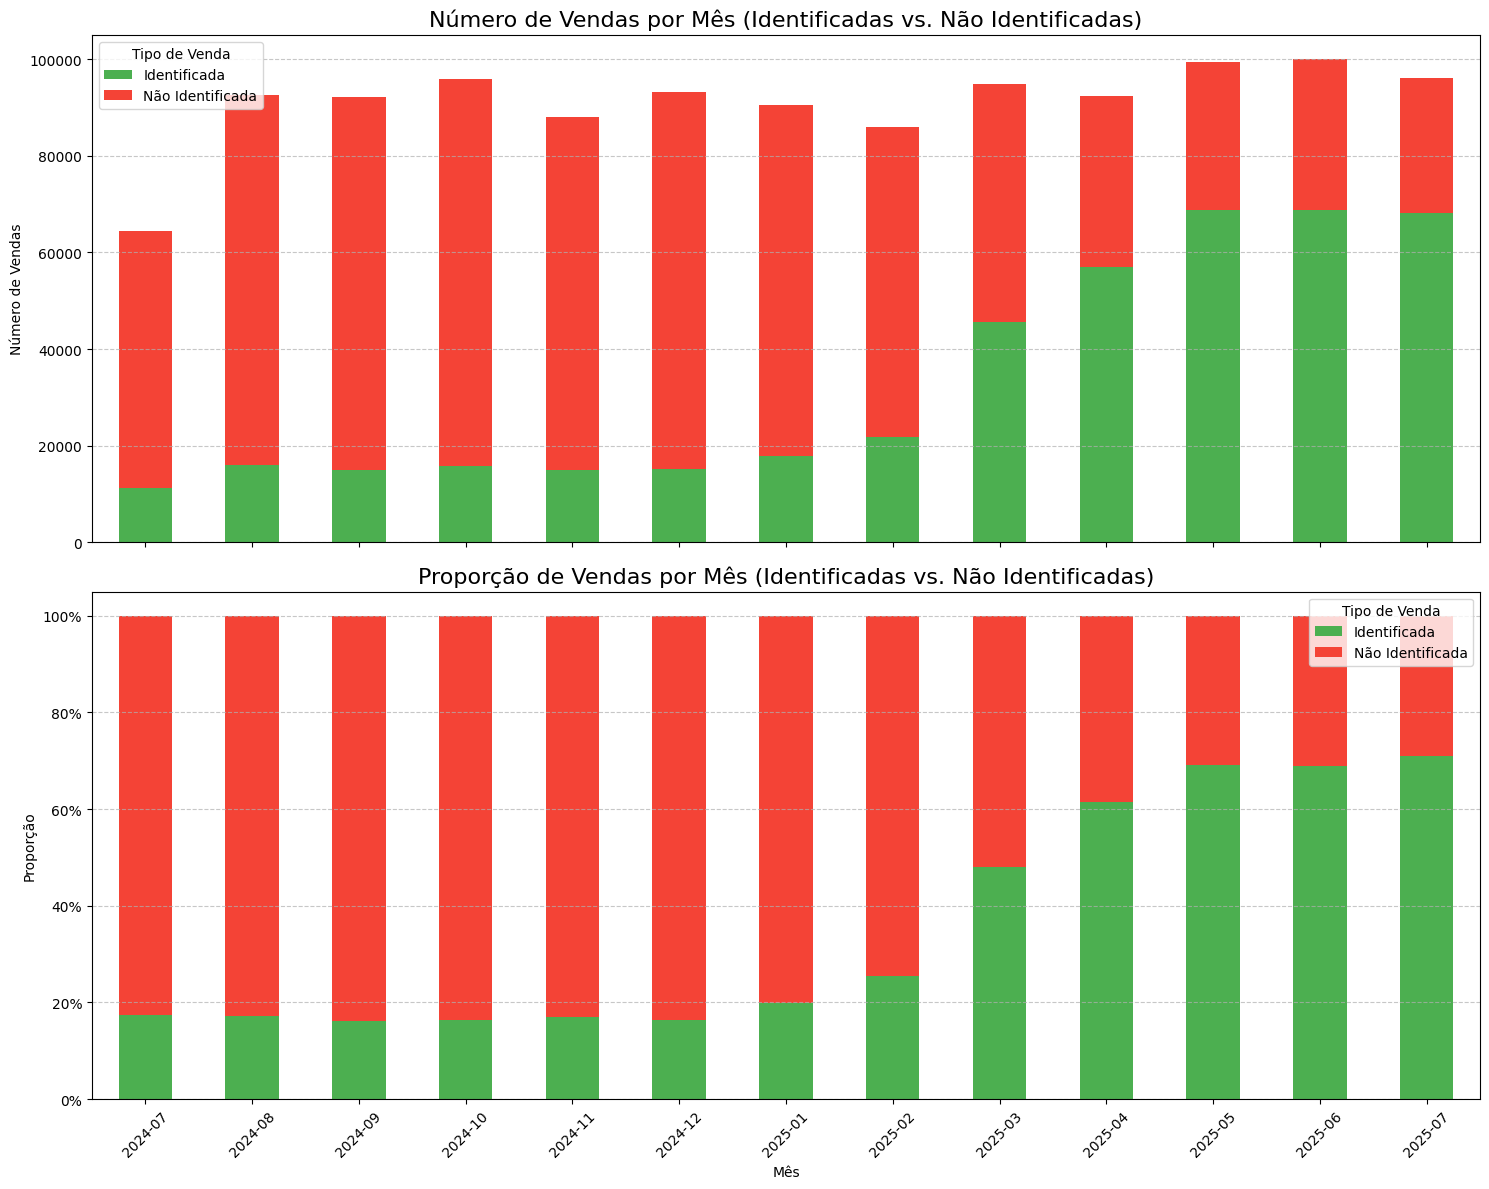

In [7]:
# 3. Visualização
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Gráfico 1: Número de Vendas por Mês
vendas_por_mes[['Identificada', 'Não Identificada']].plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#4CAF50', '#F44336']
)
axes[0].set_title('Número de Vendas por Mês (Identificadas vs. Não Identificadas)', fontsize=16)
axes[0].set_ylabel('Número de Vendas')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Tipo de Venda')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Proporção de Vendas Identificadas (100% Stacked Bar)
# Calcular as proporções
proporcoes = vendas_por_mes[['Identificada', 'Não Identificada']].div(vendas_por_mes['total'], axis=0)

proporcoes.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#4CAF50', '#F44336']
)
axes[1].set_title('Proporção de Vendas por Mês (Identificadas vs. Não Identificadas)', fontsize=16)
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Proporção')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tipo de Venda')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
# Certifique-se de que 'data_date' está em formato datetime
vendas_completas['data_date'] = pd.to_datetime(vendas_completas['data_date'])

vendas_junho_2025 = vendas_completas[
    (vendas_completas['data_date'] >= '2025-06-01') &
    (vendas_completas['data_date'] <= '2025-06-30')
]

In [11]:
vendas_junho_2025_filial = vendas_junho_2025.groupby('codigo')['item_valortotal'].sum().reset_index().sort_values(by='codigo', ascending=True)

In [14]:
import numpy as np

# Arredondar para a dezena de milhar mais próxima, para cima
vendas_junho_2025_filial['meta'] = np.ceil(vendas_junho_2025_filial['item_valortotal'] / 10000) * 10000
vendas_junho_2025_filial['meta'] = vendas_junho_2025_filial['meta'].astype(int)
vendas_junho_2025_filial[['codigo','meta']].to_csv('metas_julho.csv', index=False)

In [41]:
with open('data/preprocessados/todas_filiais_20250720_222829.pkl', 'rb') as f:
    vendas_pre = pickle.load(f)


In [45]:
import pickle

# Carregar dados
with open('data_cache/daily_pkl/final_vendas_completas.pkl', 'rb') as f:
    df = pickle.load(f)

# Ver códigos únicos
print("Códigos de filial únicos:")
print(df['codigo'].unique())
print(f"\nTipo do primeiro código: {type(df['codigo'].iloc[0])}")

Códigos de filial únicos:
['04' '06' '09' '01' '03' '12' '05' '10' '11' '08' '02' '07' '13']

Tipo do primeiro código: <class 'str'>


In [46]:
# Adicione esta célula no seu notebook:

import pickle

# 1. Carregar o PKL preprocessado
with open('data/preprocessados/todas_filiais_20250720_222829.pkl', 'rb') as f:
    dados_pkl = pickle.load(f)

print("🔍 ESTRUTURA DO PKL:")
print(f"Tipo: {type(dados_pkl)}")
print(f"Chaves (filiais): {list(dados_pkl.keys())}")

# 2. Ver primeira filial
primeira_filial = list(dados_pkl.keys())[0]
print(f"\n🔍 PRIMEIRA FILIAL: '{primeira_filial}'")
print(f"Tipo da chave: {type(primeira_filial)}")

# 3. Ver estrutura da primeira filial
if primeira_filial in dados_pkl:
    print(f"\nClassificações disponíveis:")
    print(list(dados_pkl[primeira_filial].keys())[:5])  # Primeiras 5
    
    # 4. Ver se 'todas' tem dados de vendas
    if 'todas' in dados_pkl[primeira_filial]:
        if 'vendas' in dados_pkl[primeira_filial]['todas']:
            vendas = dados_pkl[primeira_filial]['todas']['vendas']
            print(f"\nPeríodos em vendas: {list(vendas.keys())}")
            if 'por_dia' in vendas:
                print(f"Registros em por_dia: {len(vendas['por_dia'])}")

🔍 ESTRUTURA DO PKL:
Tipo: <class 'dict'>
Chaves (filiais): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13']

🔍 PRIMEIRA FILIAL: '01'
Tipo da chave: <class 'str'>

Classificações disponíveis:
['todas', 'INDICAÇÃO', 'PRESCRIÇÃO', 'SBB', 'USO_CONSUMO_E_SERVIÇOS']

Períodos em vendas: ['por_dia', 'por_semana', 'por_mes', 'ritmo']
Registros em por_dia: 19


In [34]:
vendas_completas['data_date'].max()

datetime.date(2025, 7, 20)

In [11]:
vendas_completas01 = vendas_completas[vendas_completas['venda_unidadenegocioid']==93733]

In [12]:
vendas_completas01['data_venda_apenas'] = pd.to_datetime(vendas_completas01['data_venda_apenas'], format='%Y-%m-%d')
vendas_julho_01 = vendas_completas01[(vendas_completas01['data_venda_apenas']>='2025-07-01')&(vendas_completas01['data_venda_apenas']<='2025-07-14')]

C:\Users\SetorTI\AppData\Local\Temp\ipykernel_1968\3191700093.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vendas_completas01['data_venda_apenas'] = pd.to_datetime(vendas_completas01['data_venda_apenas'], format='%Y-%m-%d')


In [25]:
data_inicio = vendas_completas01['data_venda_apenas'].min()
data_ref = date.today() - timedelta(days=1)

In [ ]:
# Keep data_date as datetime (don't convert to .date)
vendas_completas['data_date'] = pd.to_datetime(vendas_completas['data_date'])

# Ensure your date variables are also datetime
data_inicio = pd.to_datetime(data_inicio)
data_ref = pd.to_datetime(data_ref)

df_periodo = vendas_completas[
    (vendas_completas['data_date'] >= data_inicio) & 
    (vendas_completas['data_date'] <= data_ref)
].copy()
df_periodo['data_venda_apenas'] = pd.to_datetime(df_periodo['data_venda_apenas'], format='%Y-%m-%d')

df_periodo['ano_mes'] = df_periodo['data_venda_apenas'].dt.to_period('M')

vendas_mes = df_periodo.groupby('ano_mes')['venda_coo'].nunique().reset_index()
vendas_mes.rename(columns={'venda_coo': 'num_vendas'}, inplace=True)
vendas_mes['mes_formatado'] = vendas_mes['ano_mes'].astype(str)
vendas_mes = vendas_mes.sort_values('ano_mes').tail(12)
vendas_mes

,ano_mes,num_vendas,mes_formatado
1,2024-08,12054,2024-08
2,2024-09,19578,2024-09
3,2024-10,26046,2024-10
4,2024-11,27398,2024-11
5,2024-12,32847,2024-12
6,2025-01,38422,2025-01
7,2025-02,39107,2025-02
8,2025-03,45553,2025-03
9,2025-04,51380,2025-04
10,2025-05,56690,2025-05


In [39]:
vendas_mes = df_periodo.groupby('ano_mes')['venda_id'].nunique().reset_index()
vendas_mes = vendas_mes.sort_values('ano_mes').tail(12)
vendas_mes

,ano_mes,venda_id
1,2024-08,92628
2,2024-09,92208
3,2024-10,95989
4,2024-11,88074
5,2024-12,93148
6,2025-01,90457
7,2025-02,85958
8,2025-03,94984
9,2025-04,92472
10,2025-05,99526


In [38]:
vendas_mes_valor = df_periodo.groupby('ano_mes')['item_valortotal'].sum().reset_index()
vendas_mes_valor = vendas_mes_valor.sort_values('ano_mes').tail(12)
vendas_mes_valor

,ano_mes,item_valortotal
1,2024-08,4208763.18
2,2024-09,4250397.15
3,2024-10,4438953.48
4,2024-11,4088715.94
5,2024-12,4265998.91
6,2025-01,4274066.05
7,2025-02,4023999.50
8,2025-03,4590875.68
9,2025-04,4455301.79
10,2025-05,4846985.40


In [32]:
import calendar
data_ref = date.today() - timedelta(days=1)
dia_atual = data_ref.day

resultados = []

for i in range(12):
    if data_ref.month - i <= 0:
        mes_ref = 12 + (data_ref.month - i)
        ano_ref = data_ref.year - 1
    else:
        mes_ref = data_ref.month - i
        ano_ref = data_ref.year
    # Keep data_date as datetime (don't convert to .date)
    vendas_completas01['data_date'] = pd.to_datetime(vendas_completas01['data_date'])

    # Ensure your date variables are also datetime
    data_inicio = pd.to_datetime(data_inicio)
    data_ref = pd.to_datetime(data_ref)


    ultimo_dia_mes = calendar.monthrange(ano_ref, mes_ref)[1]
    dia_limite = min(dia_atual, ultimo_dia_mes)

    data_inicio_mes = pd.to_datetime(date(ano_ref, mes_ref, 1))
    data_fim_mes = pd.to_datetime(date(ano_ref, mes_ref, dia_limite))

    df_mes = vendas_completas01[
        (vendas_completas01['data_date'] >= data_inicio_mes) & 
        (vendas_completas01['data_date'] <= data_fim_mes)
    ].copy()

    num_vendas_total = df_mes['venda_coo'].nunique() if not df_mes.empty else 0

    resultados.append({
        'ano_mes': f"{ano_ref}-{mes_ref:02d}",
        'mes_formatado': f"{calendar.month_abbr[mes_ref]}/{ano_ref}",
        'num_vendas_acumuladas': num_vendas_total,
        'dias_considerados': dia_limite
    })

    df_ritmo = pd.DataFrame(resultados)
df_ritmo

C:\Users\SetorTI\AppData\Local\Temp\ipykernel_1968\3169630540.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vendas_completas01['data_date'] = pd.to_datetime(vendas_completas01['data_date'])
C:\Users\SetorTI\AppData\Local\Temp\ipykernel_1968\3169630540.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vendas_completas01['data_date'] = pd.to_datetime(vendas_completas01['data_date'])
C:\Users\SetorTI\AppData\Local\Temp\ipykernel_1968\3169630540.py:15: SettingWithCopyWarning: 
A value is trying to be 

,ano_mes,mes_formatado,num_vendas_acumuladas,dias_considerados
0,2025-07,jul/2025,7325,19
1,2025-06,jun/2025,9422,19
2,2025-05,mai/2025,9179,19
3,2025-04,abr/2025,9290,19
4,2025-03,mar/2025,9332,19
5,2025-02,fev/2025,9224,19
6,2025-01,jan/2025,8262,19
7,2024-12,dez/2024,5939,19
8,2024-11,nov/2024,6308,19
9,2024-10,out/2024,6487,19


In [13]:
vendas_julho_01.agg({
    'item_valortotal':'sum',
    'venda_coo':'nunique',
    'item_quantidade':'sum',
    'valordescontototal':'sum'
})

item_valortotal       360884.46
venda_coo               7266.00
item_quantidade        17550.00
valordescontototal    196516.01
dtype: float64

In [14]:
360884.46/7266.0

49.667555739058635

In [20]:
vendas_completas['codigo'].unique()

array(['04', '06', '09', '01', '03', '12', '05', '10', '11', '08', '02',
       '07', '13'], dtype=object)

In [140]:
custo01 = custoproduto[custoproduto['unidadenegocioid']==93733][['produtoid','custo','customedio']]

In [144]:
venda01 = venda01.merge(custo01, how='left', left_on='produto_id', right_on='produtoid')

In [153]:
venda01['custototal'] = venda01['item_quantidade'] * venda01['custo']
venda01['customediototal'] = venda01['item_quantidade'] * venda01['customedio']

In [154]:
resumo01 = venda01.agg({
    'item_valortotal': 'sum',
    'item_quantidade': 'sum',
    'venda_coo': 'nunique',
    'item_valordesconto': 'sum',
    'custototal': 'sum',
    'customediototal': 'sum'
}).reset_index()

In [155]:
resumo01

,index,0
0,item_valortotal,338379.8000
1,item_quantidade,16475.0000
2,venda_coo,6814.0000
3,item_valordesconto,181857.2200
4,custototal,240377.9760
5,customediototal,240191.8478


In [132]:
338379.8 / 6814.0

49.659495157029646

In [156]:
240191.8478/338379.8

0.7098291558775081

In [86]:
categorias = venda01.groupby('classificacao_n1')['item_valortotal'].sum().reset_index().sort_values('item_valortotal', ascending=False)
categorias['proporção'] = categorias['item_valortotal'] / categorias['item_valortotal'].sum() * 100
categorias

,classificacao_n1,item_valortotal,proporção
1,PRESCRIÇÃO,124027.78,36.653423
0,INDICAÇÃO,121751.35,35.980679
3,VAREJO,48006.45,14.187150
2,SBB,44594.22,13.178748


In [80]:
venda01.columns

Index(['venda_status', 'venda_coo', 'valor_total', 'venda_id', 'venda_caixaid',
       'venda_unidadenegocioid', 'venda_usuarioid', 'venda_pessoaid',
       'venda_orcamentoid', 'venda_tipodocfiscal', 'venda_datahoraabertura',
       'venda_datahorafechamento', 'data_venda_apenas', 'item_sequencia',
       'item_vendaid', 'item_embalagemid', 'item_status', 'item_tipoaliquota',
       'item_quantidade', 'item_valorunitario', 'item_origemdesconto',
       'item_tipodesconto', 'item_desconto', 'item_valortotal',
       'item_cadernoofertaid', 'item_valordesconto',
       'item_movimentacaoestoque', 'item_diasparavencimento', 'embalagem_id',
       'embalagem_produtoid', 'embalagem_codigobarras', 'embalagem_etiqueta',
       'embalagem_descricao', 'embalagem_apresentacao',
       'embalagem_quantidadeporembalagem', 'embalagem_padraofornecedores',
       'embalagem_precoreferencial', 'embalagem_markup',
       'embalagem_precovenda', 'embalagem_precovendavariavel', 'produto_id',
       'pro

In [9]:
Venda = 338880.01
ItemVenda = 338379.8

338529.75